## 🔧 Imports and Environment Configuration

This section initializes all required libraries and configures the execution environment for building, training, and evaluating a Convolutional Neural Network (CNN) for Arabic Sign Language classification.

The imports cover:
- Numerical computation and data handling
- Data visualization
- Deep learning with TensorFlow/Keras
- Image preprocessing and augmentation
- Model evaluation metrics
- System and file handling utilities

Additionally, this section ensures reproducibility, configures GPU usage, and suppresses unnecessary warnings.


In [56]:
# IMPORTS AND CONFIGURATION
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import class_weight
import os
import cv2
from pathlib import Path
import warnings
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
import yaml
from collections import Counter
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU Configuration
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    # Enable memory growth to prevent OOM errors
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled")
    

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU memory growth enabled


## ⚡ Quick Run Mode Configuration

This flag controls whether the notebook runs in **full training mode** or **quick test mode**.

- When enabled, the pipeline runs with reduced data and fewer epochs for fast debugging.
- When disabled, the full dataset and complete training configuration are used for final experiments.


In [57]:

QUICK_RUN_MODE = False 


In [58]:
import os

os.listdir('/kaggle/input')


['arabic-sign-language-unaugmented-dataset']

In [59]:
os.listdir('/kaggle/input/arabic-sign-language-unaugmented-dataset')


['unaugmented']

## 📄 YAML Data Loading for Class Information

This code snippet is used to **read dataset metadata** from a YAML file, typically for deep learning tasks like classification.


In [60]:
with open(os.path.join(BASE_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)


In [61]:

yaml_path = os.path.join(BASE_PATH, 'data.yaml')

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Classes:", class_names)


Number of classes: 28
Classes: ['ALIF', 'BAA', 'TA', 'THA', 'JEEM', 'HAA', 'KHAA', 'DELL', 'DHELL', 'RAA', 'ZAY', 'SEEN', 'SHEEN', 'SAD', 'DAD', 'TAA', 'DHAA', 'AYN', 'GHAYN', 'FAA', 'QAAF', 'KAAF', 'LAAM', 'MEEM', 'NOON', 'HA', 'WAW', 'YA']


In [62]:

# DATA PATHS AND CONSTANTS (KAGGLE - VERIFIED)

BASE_PATH = (
    '/kaggle/input/'
    'arabic-sign-language-unaugmented-dataset/'
    'unaugmented/'
    '416'
)

TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VAL_PATH   = os.path.join(BASE_PATH, 'valid')   # NOTE: valid (not val)
TEST_PATH  = os.path.join(BASE_PATH, 'test')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

 # PATH VERIFICATION

print("BASE CONTENT:", os.listdir(BASE_PATH))
print("TRAIN CONTENT:", os.listdir(TRAIN_PATH))
print("VALID CONTENT:", os.listdir(VAL_PATH))
print("TEST CONTENT:", os.listdir(TEST_PATH))


BASE CONTENT: ['data.yaml', 'valid', 'test', 'train']
TRAIN CONTENT: ['labels', 'data.yaml', 'images']
VALID CONTENT: ['labels', 'data.yaml', 'images']
TEST CONTENT: ['labels', 'data.yaml', 'images']


In [63]:

# LOAD CLASS NAMES FROM data.yaml

yaml_path = os.path.join(BASE_PATH, 'data.yaml')

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

print(f"Number of classes: {NUM_CLASSES}")
print("Classes:", CLASS_NAMES)


Number of classes: 28
Classes: ['ALIF', 'BAA', 'TA', 'THA', 'JEEM', 'HAA', 'KHAA', 'DELL', 'DHELL', 'RAA', 'ZAY', 'SEEN', 'SHEEN', 'SAD', 'DAD', 'TAA', 'DHAA', 'AYN', 'GHAYN', 'FAA', 'QAAF', 'KAAF', 'LAAM', 'MEEM', 'NOON', 'HA', 'WAW', 'YA']


## YOLO Dataset Analysis 

- Counts annotations per class in a YOLO-format dataset split.  
- Plots class distribution as a bar chart to visualize imbalance.  
- Computes statistics: total, min, max, mean, std, and imbalance ratio.  
- Returns a DataFrame for further analysis or reporting.  


In [66]:

# YOLO DATASET ANALYSIS FUNCTION

def analyze_yolo_dataset(split_path, title):
    """
    Analyze YOLO-format dataset by counting annotations per class
    """

    labels_path = os.path.join(split_path, 'labels')
    counter = Counter()

    for label_file in os.listdir(labels_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_path, label_file), 'r') as f:
                for line in f:
                    class_id = int(line.split()[0])
                    counter[class_id] += 1

    counts = [counter[i] for i in range(NUM_CLASSES)]

    # Plot
    plt.figure(figsize=(16, 5))
    plt.bar(CLASS_NAMES, counts)
    plt.title(f"{title} - Class Distribution", fontsize=16, fontweight='bold')
    plt.xlabel("Class")
    plt.ylabel("Number of Annotations")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Statistics
    df = pd.DataFrame({
        "Class": CLASS_NAMES,
        "Count": counts
    })

    print("=" * 60)
    print(f"{title} - Statistical Summary")
    print("=" * 60)
    print(f"Total annotations: {df['Count'].sum()}")
    print(f"Min annotations per class: {df['Count'].min()}")
    print(f"Max annotations per class: {df['Count'].max()}")
    print(f"Mean annotations per class: {df['Count'].mean():.1f}")
    print(f"Std deviation: {df['Count'].std():.1f}")
    print(f"Imbalance ratio (max/min): {df['Count'].max() / max(df['Count'].min(), 1):.2f}x")
    print("=" * 60)

    return df



EXPLORATORY DATA ANALYSIS



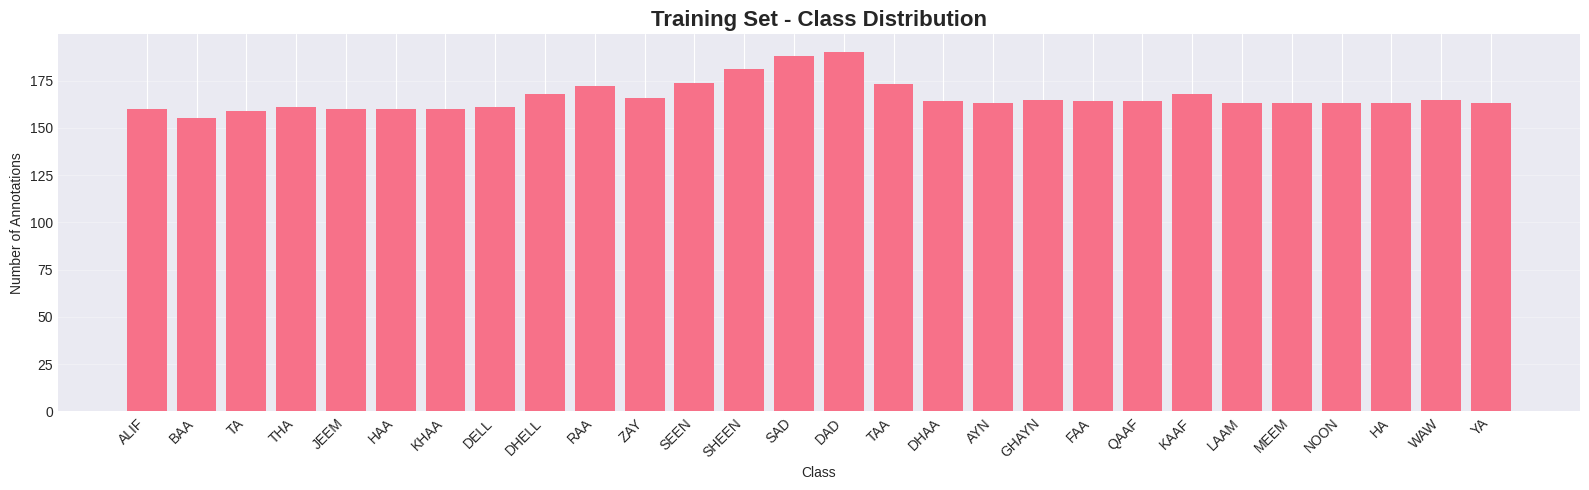

Training Set - Statistical Summary
Total annotations: 4656
Min annotations per class: 155
Max annotations per class: 190
Mean annotations per class: 166.3
Std deviation: 8.3
Imbalance ratio (max/min): 1.23x


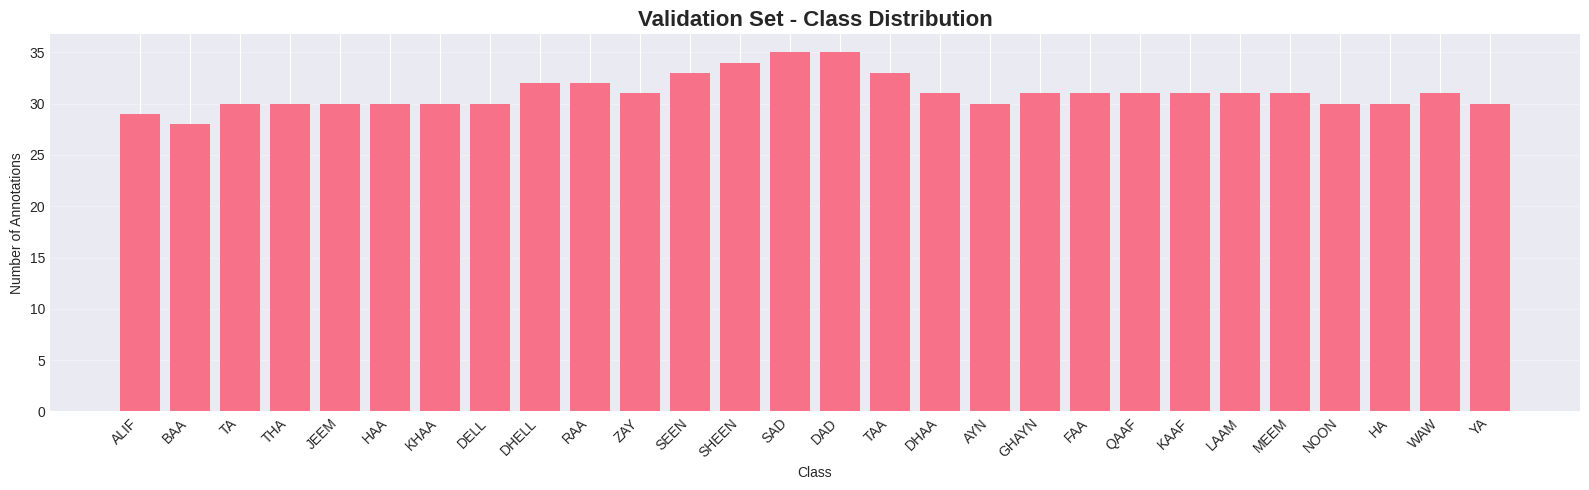

Validation Set - Statistical Summary
Total annotations: 870
Min annotations per class: 28
Max annotations per class: 35
Mean annotations per class: 31.1
Std deviation: 1.7
Imbalance ratio (max/min): 1.25x


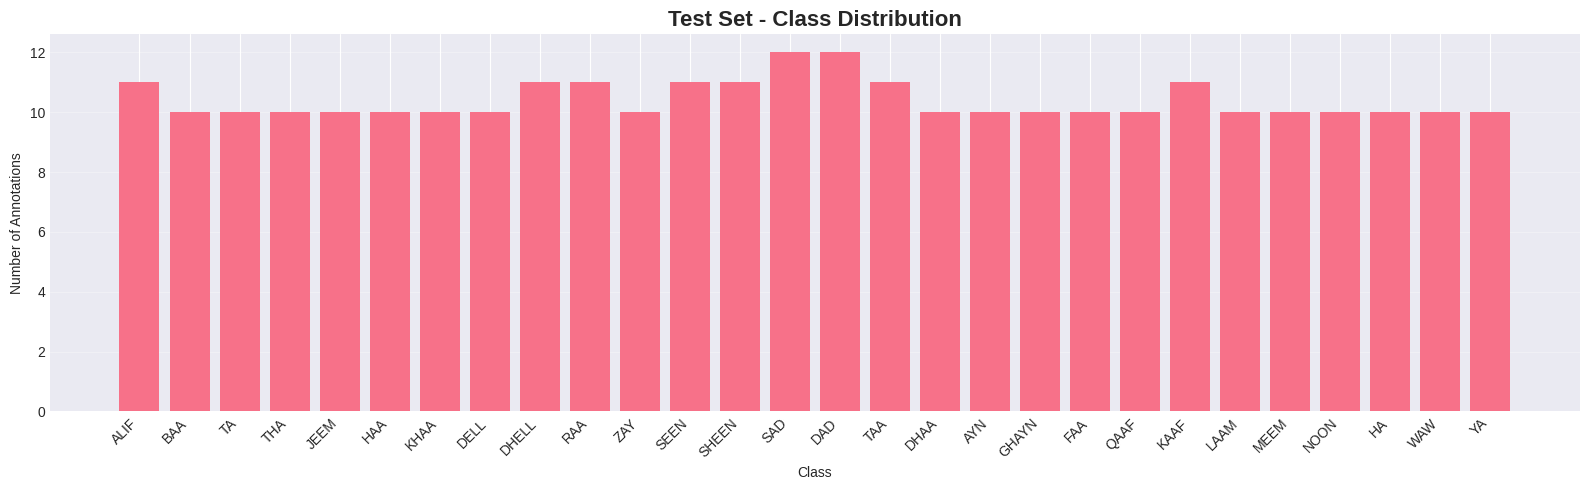

Test Set - Statistical Summary
Total annotations: 291
Min annotations per class: 10
Max annotations per class: 12
Mean annotations per class: 10.4
Std deviation: 0.6
Imbalance ratio (max/min): 1.20x


In [67]:
# RUN EDA ON ALL SPLITS


print("\nEXPLORATORY DATA ANALYSIS\n")

train_df = analyze_yolo_dataset(TRAIN_PATH, "Training Set")
val_df   = analyze_yolo_dataset(VAL_PATH, "Validation Set")
test_df  = analyze_yolo_dataset(TEST_PATH, "Test Set")


# SAMPLE IMAGE VISUALIZATION



Visualizing training samples...



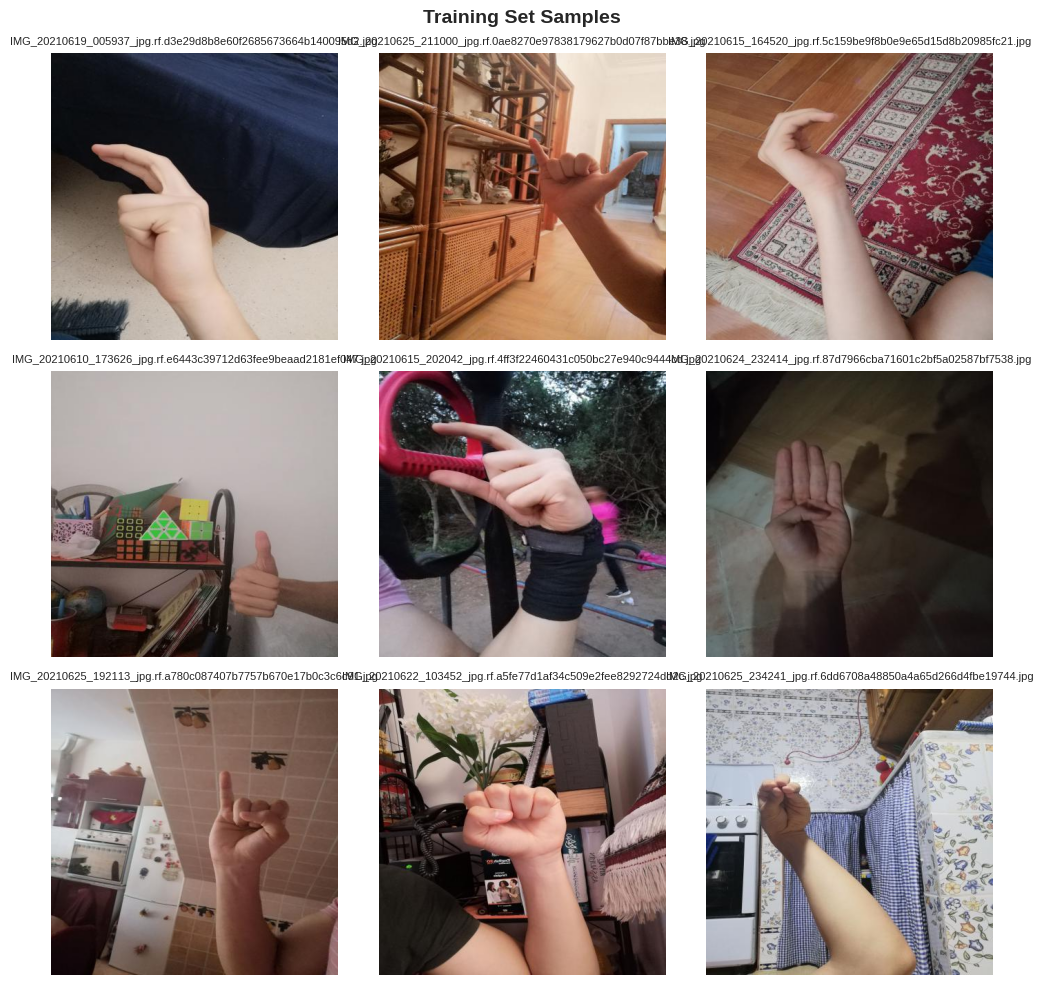


Image Properties Analysis
Images analyzed: 100
Most common resolution: (416, 416)
Color channels: 3


In [68]:


def visualize_samples(split_path, num_samples=9, title="Sample Images"):
    """
    Display sample images from YOLO dataset
    """
    images_path = os.path.join(split_path, 'images')
    image_files = os.listdir(images_path)[:num_samples]

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    for i, img_name in enumerate(image_files):
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(img_name, fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\nVisualizing training samples...\n")
visualize_samples(TRAIN_PATH, title="Training Set Samples")

# IMAGE PROPERTY ANALYSIS

def analyze_image_properties(split_path, num_samples=100):
    """
    Analyze image resolution and channels
    """
    images_path = os.path.join(split_path, 'images')
    sizes = []
    channels = []

    for img_name in os.listdir(images_path)[:num_samples]:
        img = cv2.imread(os.path.join(images_path, img_name))
        if img is not None:
            sizes.append(img.shape[:2])
            channels.append(img.shape[2])

    print("\nImage Properties Analysis")
    print("=" * 60)
    print(f"Images analyzed: {len(sizes)}")
    print(f"Most common resolution: {max(set(sizes), key=sizes.count)}")
    print(f"Color channels: {max(set(channels), key=channels.count)}")
    print("=" * 60)

analyze_image_properties(TRAIN_PATH)


In [69]:
# CLASS WEIGHT CALCULATION


print("\n⚖️ HANDLING CLASS IMBALANCE\n")

# Only take directories (ignore files like data.yaml)
class_labels = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
class_samples = [len(os.listdir(os.path.join(TRAIN_PATH, cls))) for cls in class_labels]

# Compute balanced class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_labels)),
    y=[i for i, cnt in enumerate(class_samples) for _ in range(cnt)]
)

# Create dictionary for Keras
class_weights_dict = dict(enumerate(class_weights_array))

# Display weights
print("Class Weights (Higher weight = Lower frequency):")
print("="*60)
weight_df = pd.DataFrame({
    'Class': class_labels,
    'Sample Count': class_samples,
    'Weight': class_weights_array
}).sort_values('Weight', ascending=False)
print(weight_df.head(10).to_string(index=False))
print(f"\nMin weight: {class_weights_array.min():.3f}")
print(f"Max weight: {class_weights_array.max():.3f}")
print(f"Mean weight: {class_weights_array.mean():.3f}")
print("="*60 + "\n")



⚖️ HANDLING CLASS IMBALANCE

Class Weights (Higher weight = Lower frequency):
 Class  Sample Count  Weight
images          4651     1.0
labels          4651     1.0

Min weight: 1.000
Max weight: 1.000
Mean weight: 1.000



## 🎨 Data Augmentation & Generators 

- **Purpose:** Applied because the dataset is **imbalanced** across classes to improve generalization.  
- **Training Augmentation:** rotation ±20°, shift ±10%, shear 10%, zoom ±15%, horizontal flip, brightness 80%-120%, rescaling 1/255.  
- **Validation/Test:** only rescaling (no augmentation).  
- **Data Generators & Visualization:** create batches with categorical labels; `show_augmented_images` displays sample augmented training images with class names.  


In [70]:

# DATA AUGMENTATION STRATEGY


print("🎨 DATA AUGMENTATION CONFIGURATION\n")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Augmentation Strategy:")
print("="*60)
print("Training Set:")
print("  • Rotation: ±20°")
print("  • Translation: ±10%")
print("  • Zoom: ±15%")
print("  • Horizontal Flip: Yes")
print("  • Brightness: 80%-120%")
print("\nValidation/Test Sets:")
print("  • Only normalization (no augmentation)")
print("="*60 + "\n")


🎨 DATA AUGMENTATION CONFIGURATION

Augmentation Strategy:
Training Set:
  • Rotation: ±20°
  • Translation: ±10%
  • Zoom: ±15%
  • Horizontal Flip: Yes
  • Brightness: 80%-120%

Validation/Test Sets:
  • Only normalization (no augmentation)



In [71]:

# DATA GENERATORS

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("✅ Data Generators Created:")
print("="*60)
print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {val_generator.samples:,}")
print(f"Test samples: {test_generator.samples:,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Steps per epoch (train): {len(train_generator)}")
print(f"Steps per epoch (val): {len(val_generator)}")
print("="*60 + "\n")


Found 4651 images belonging to 2 classes.
Found 891 images belonging to 2 classes.
Found 290 images belonging to 2 classes.
✅ Data Generators Created:
Training samples: 4,651
Validation samples: 891
Test samples: 290
Batch size: 32
Steps per epoch (train): 146
Steps per epoch (val): 28



# VISUALIZE AUGMENTED IMAGES


🖼️ Sample Augmented Images:



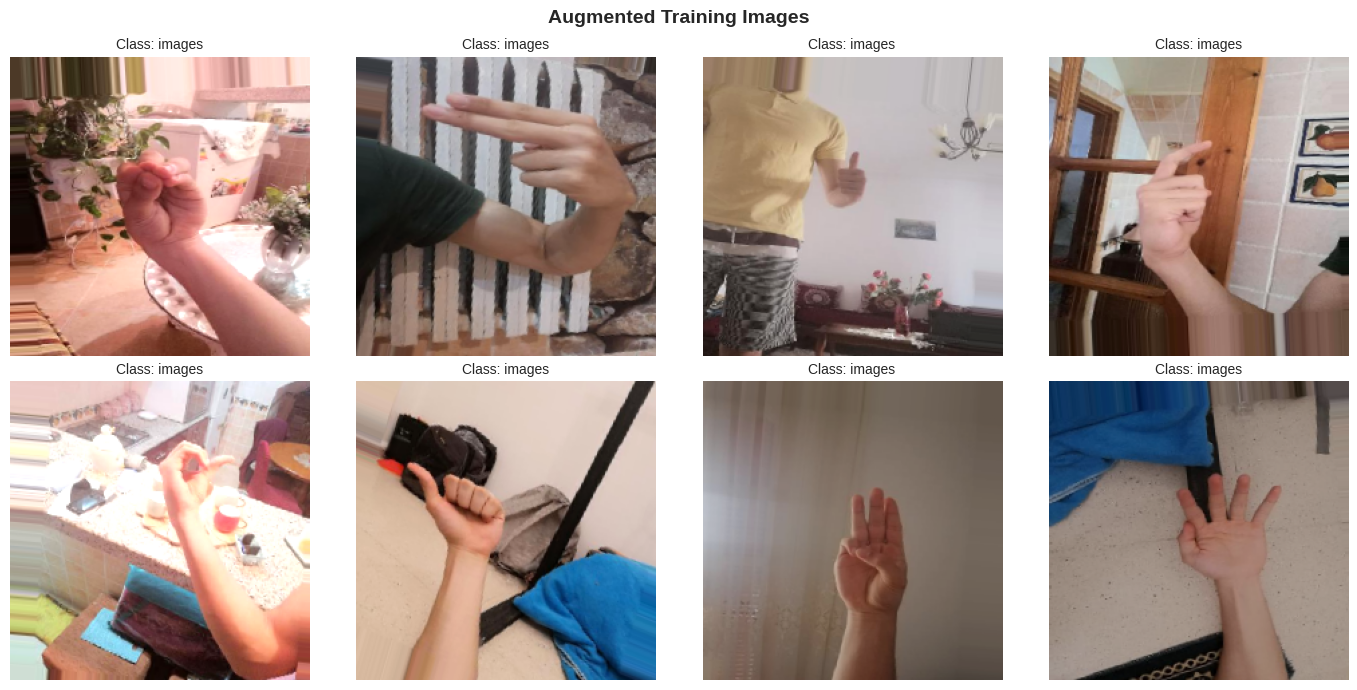

In [72]:


def show_augmented_images(generator, num_images=8):
    x_batch, y_batch = next(generator)
    
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    
    for i in range(min(num_images, len(x_batch))):
        axes[i].imshow(x_batch[i])
        class_idx = np.argmax(y_batch[i])
        class_name = list(generator.class_indices.keys())[class_idx]
        axes[i].set_title(f'Class: {class_name}', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("🖼️ Sample Augmented Images:\n")
show_augmented_images(train_generator)


In [73]:
# YOLO → CLASSIFICATION FOLDER STRUCTURE

# Paths
BASE_PATH = '/kaggle/input/arabic-sign-language-unaugmented-dataset/unaugmented/416'
SPLITS = ['train', 'valid', 'test']
OUTPUT_BASE = '/kaggle/working/ASL_classification'  # new output folder

# Load class names

with open(os.path.join(BASE_PATH, 'data.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)
print(f"Number of classes: {NUM_CLASSES}")
print("Classes:", CLASS_NAMES)


# Create output folder structure

for split in SPLITS:
    for cls in CLASS_NAMES:
        Path(os.path.join(OUTPUT_BASE, split, cls)).mkdir(parents=True, exist_ok=True)


Number of classes: 28
Classes: ['ALIF', 'BAA', 'TA', 'THA', 'JEEM', 'HAA', 'KHAA', 'DELL', 'DHELL', 'RAA', 'ZAY', 'SEEN', 'SHEEN', 'SAD', 'DAD', 'TAA', 'DHAA', 'AYN', 'GHAYN', 'FAA', 'QAAF', 'KAAF', 'LAAM', 'MEEM', 'NOON', 'HA', 'WAW', 'YA']


In [74]:

# Conversion function

def yolo_to_classification(split):
    img_dir = os.path.join(BASE_PATH, split, 'images')
    label_dir = os.path.join(BASE_PATH, split, 'labels')
    
    img_files = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    count = 0

    for img_name in img_files:
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, img_name.replace(os.path.splitext(img_name)[1], '.txt'))

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        # Read label
        if not os.path.exists(label_path):
            continue
        with open(label_path, 'r') as f:
            lines = f.readlines()
            if len(lines) == 0:
                continue

            for i, line in enumerate(lines):
                parts = line.strip().split()
                cls_id = int(parts[0])
                x_c, y_c, bw, bh = map(float, parts[1:])

                x1 = int((x_c - bw/2) * w)
                y1 = int((y_c - bh/2) * h)
                x2 = int((x_c + bw/2) * w)
                y2 = int((y_c + bh/2) * h)

                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(w, x2), min(h, y2)

                cropped = img[y1:y2, x1:x2]
                if cropped.size == 0:
                    continue

                out_path = os.path.join(OUTPUT_BASE, split, CLASS_NAMES[cls_id], f"{os.path.splitext(img_name)[0]}_{i}.jpg")
                cv2.imwrite(out_path, cropped)
                count += 1

    print(f"{split} → converted {count} images")


In [76]:

# Run conversion

for split in SPLITS:
    yolo_to_classification(split)

print("\n✅ YOLO → Classification folders conversion completed!")
print(f"New dataset location: {OUTPUT_BASE}")


train → converted 4656 images
valid → converted 869 images
test → converted 291 images

✅ YOLO → Classification folders conversion completed!
New dataset location: /kaggle/working/ASL_classification


# FINAL DATASET SETUP + CLASS WEIGHTS + AUGMENTATION


In [77]:

# Paths (after YOLO → Classification conversion)

OUTPUT_BASE = '/kaggle/working/ASL_classification'  # new converted dataset
TRAIN_PATH = os.path.join(OUTPUT_BASE, 'train')
VAL_PATH   = os.path.join(OUTPUT_BASE, 'valid')
TEST_PATH  = os.path.join(OUTPUT_BASE, 'test')

IMG_SIZE = 224
BATCH_SIZE = 32


# CLASS WEIGHT CALCULATION
print("\n⚖️ HANDLING CLASS IMBALANCE\n")

# Only directories (each directory = one class)
class_labels = sorted([d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))])
class_samples = [len(os.listdir(os.path.join(TRAIN_PATH, cls))) for cls in class_labels]

# Compute balanced class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_labels)),
    y=[i for i, cnt in enumerate(class_samples) for _ in range(cnt)]
)
class_weights_dict = dict(enumerate(class_weights_array))

# Display weights
print("Class Weights (Higher weight = Lower frequency):")
print("="*60)
weight_df = pd.DataFrame({
    'Class': class_labels,
    'Sample Count': class_samples,
    'Weight': class_weights_array
}).sort_values('Weight', ascending=False)
print(weight_df.head(10).to_string(index=False))
print(f"\nMin weight: {class_weights_array.min():.3f}")
print(f"Max weight: {class_weights_array.max():.3f}")
print(f"Mean weight: {class_weights_array.mean():.3f}")
print("="*60 + "\n")


⚖️ HANDLING CLASS IMBALANCE

Class Weights (Higher weight = Lower frequency):
Class  Sample Count   Weight
  BAA           155 1.072811
   TA           159 1.045822
 JEEM           160 1.039286
 ALIF           160 1.039286
 KHAA           160 1.039286
  HAA           160 1.039286
 DELL           161 1.032831
  THA           161 1.032831
 LAAM           163 1.020158
  AYN           163 1.020158

Min weight: 0.875
Max weight: 1.073
Mean weight: 1.002



## 🧠 Custom CNN Architecture for Arabic Sign Language Recognition

In this section, we design and implement a **custom Convolutional Neural Network (CNN)** specifically tailored for **Arabic Sign Language (ArSL) image classification**.

The architecture is built from scratch to balance:
- Feature extraction power
- Generalization capability
- Overfitting control
- Computational efficiency

---

### 🎯 Design Objectives

The proposed CNN architecture aims to:

- Capture **hierarchical visual features** of hand gestures
- Handle **intra-class variation** (rotation, lighting, hand position)
- Mitigate **overfitting** using regularization techniques
- Scale progressively from simple to complex features

---

### 🏗️ Architecture Design Philosophy

The model follows a **progressive deep CNN design**, where the number of filters increases gradually:

| Block | Filters | Purpose |
|-----|--------|--------|
| Block 1 | 32  | Edge & texture detection |
| Block 2 | 64  | Shape & contour extraction |
| Block 3 | 128 | Hand structure recognition |
| Block 4 | 256 | High-level gesture semantics |

Each convolutional block includes:
- Convolution layer (Conv2D)
- Batch Normalization
- ReLU activation
- Max Pooling
- Dropout regularization

---

### 🧩 Regularization & Stability Techniques

To ensure stable and robust training:

- **Batch Normalization** is applied after each convolution and dense layer to:
  - Reduce internal covariate shift
  - Enable faster convergence

- **Dropout** is progressively increased:
  - Prevents co-adaptation of neurons
  - Reduces overfitting on imbalanced data

- **L2 Weight Regularization**:
  - Penalizes large weights
  - Encourages smoother decision boundaries

---

### 🧠 Classification Head (Dense Layers)

After convolutional feature extraction:
- Feature maps are flattened
- Two fully connected layers (512 → 256 neurons)
- Final Softmax layer outputs class probabilities

---

### 📥 Input & 📤 Output Specifications

- **Input Shape:** `(IMG_SIZE, IMG_SIZE, 3)`
- **Output:** `NUM_CLASSES` probabilities using Softmax
- **Loss Function:** Categorical Cross-Entropy
- **Optimizer:** Adam (learning rate = 0.001)

---

### 🛠️ Model Compilation

The model is compiled with the following metrics:
- Accuracy
- Precision
- Recall  

This enables detailed evaluation beyond accuracy alone, which is critical for multi-class gesture recognition tasks.

---

### 📊 Model Summary & Visualization

The architecture summary provides:
- Layer-by-layer details
- Output shapes
- Parameter counts

Additionally, a **visual architecture diagram** is generated and saved as:



In [85]:
# CUSTOM CNN ARCHITECTURE


def build_arsl_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Custom CNN Architecture for Arabic Sign Language Classification
    
    Architecture Design Philosophy:
    -------------------------------
    • Progressive Feature Extraction: 32 → 64 → 128 → 256 filters
    • Batch Normalization: Stabilizes training, enables higher learning rates
    • Dropout Regularization: Prevents overfitting (critical for imbalanced data)
    • MaxPooling: Spatial invariance for hand position/orientation
    • Dense Layers: High-level feature integration and classification
    
    Layer-by-Layer Rationale:
    ------------------------
    Block 1 (32 filters):  Low-level features (edges, textures)
    Block 2 (64 filters):  Mid-level features (shapes, contours)
    Block 3 (128 filters): High-level features (hand structures)
    Block 4 (256 filters): Complex patterns (gesture semantics)
    
    Parameters:
        input_shape: Input image dimensions (H, W, C)
        num_classes: Number of output classes
    
    Returns:
        Compiled Keras model
    """
    
    model = models.Sequential(name='ArSL_CNN')
    
    # CONVOLUTIONAL BLOCK 1: Edge and Texture Detection
    
    model.add(layers.Input(shape=input_shape, name='input_layer'))
    
    model.add(layers.Conv2D(
        32, (3, 3), 
        padding='same', 
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='conv1'
    ))
    model.add(layers.BatchNormalization(name='bn1'))
    model.add(layers.Activation('relu', name='relu1'))
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))
    model.add(layers.Dropout(0.25, name='dropout1'))
    
    
    # CONVOLUTIONAL BLOCK 2: Shape and Contour Detection
    
    model.add(layers.Conv2D(
        64, (3, 3), 
        padding='same',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='conv2'
    ))
    model.add(layers.BatchNormalization(name='bn2'))
    model.add(layers.Activation('relu', name='relu2'))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))
    model.add(layers.Dropout(0.3, name='dropout2'))
    
    
    # CONVOLUTIONAL BLOCK 3: Hand Structure Recognition
    
    model.add(layers.Conv2D(
        128, (3, 3), 
        padding='same',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='conv3'
    ))
    model.add(layers.BatchNormalization(name='bn3'))
    model.add(layers.Activation('relu', name='relu3'))
    model.add(layers.MaxPooling2D((2, 2), name='pool3'))
    model.add(layers.Dropout(0.35, name='dropout3'))
    
    
    # CONVOLUTIONAL BLOCK 4: Gesture Semantics
    
    model.add(layers.Conv2D(
        256, (3, 3), 
        padding='same',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='conv4'
    ))
    model.add(layers.BatchNormalization(name='bn4'))
    model.add(layers.Activation('relu', name='relu4'))
    model.add(layers.MaxPooling2D((2, 2), name='pool4'))
    model.add(layers.Dropout(0.4, name='dropout4'))
    
    
    # DENSE LAYERS: Classification Head
    
    model.add(layers.Flatten(name='flatten'))
    
    # First Dense Layer
    model.add(layers.Dense(
        512, 
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='dense1'
    ))
    model.add(layers.BatchNormalization(name='bn_dense1'))
    model.add(layers.Activation('relu', name='relu_dense1'))
    model.add(layers.Dropout(0.5, name='dropout_dense1'))
    
    # Second Dense Layer
    model.add(layers.Dense(
        256, 
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='dense2'
    ))
    model.add(layers.BatchNormalization(name='bn_dense2'))
    model.add(layers.Activation('relu', name='relu_dense2'))
    model.add(layers.Dropout(0.5, name='dropout_dense2'))
    
    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    
    return model


# BUILD AND COMPILE MODEL


print("\n🏗️ BUILDING CNN ARCHITECTURE\n")

model = build_arsl_cnn()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Display architecture
print("="*70)
print("CNN ARCHITECTURE SUMMARY")
print("="*70 + "\n")
model.summary()

# Calculate parameters
total_params = model.count_params()
print(f"\n{'='*70}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {total_params:,}")
print(f"Model Size (approximate): {total_params * 4 / (1024**2):.2f} MB")
print(f"{'='*70}\n")

# Create architecture visualization
keras.utils.plot_model(
    model,
    to_file='arsl_cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # Top to Bottom
    expand_nested=True,
    dpi=96
)
print("✅ Architecture diagram saved as 'arsl_cnn_architecture.png'\n")


🏗️ BUILDING CNN ARCHITECTURE

CNN ARCHITECTURE SUMMARY



Model: "ArSL_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense1 (BatchNormalization)  │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_dense1 (Activation)        │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense1 (Dropout)        │ (None, 512)            │             

 Total params: 26,222,556 (100.03 MB)

 Trainable params: 26,220,060 (100.02 MB)

 Non-trainable params: 2,496 (9.75 KB)


Total Parameters: 26,222,556
Trainable Parameters: 26,222,556
Model Size (approximate): 100.03 MB

✅ Architecture diagram saved as 'arsl_cnn_architecture.png'



In [94]:
import os
print(os.getcwd())
print(os.listdir('.'))

/kaggle/working
['logs', '.virtual_documents', 'training_history.csv', 'best_arsl_model.keras', 'ASL_classification', 'arsl_cnn_architecture.png']


## 🧠 Training Callbacks & Execution – Explanation

This cell is responsible for **configuring training callbacks** and **controlling how the model is trained or loaded** depending on the run mode. It improves training efficiency, stability, and experiment tracking.

---

## ⚙️ Training Callbacks Configuration

Callbacks are automated utilities that monitor training and take actions without manual intervention.

### 1️⃣ EarlyStopping
- **Purpose:** Prevent overfitting by stopping training when validation loss stops improving.
- **Monitor:** `val_loss`
- **Patience:** 15 epochs
- **Restore Best Weights:** Yes (best model is kept)
- **Effect:** Training halts once no improvement is observed for 15 epochs.

---

### 2️⃣ ModelCheckpoint
- **Purpose:** Save the best-performing model during training.
- **Monitor:** `val_accuracy`
- **Condition:** Save only when validation accuracy improves.
- **File Saved:** `best_arsl_model.keras`
- **Effect:** Guarantees that the highest-accuracy model is preserved.

---

### 3️⃣ ReduceLROnPlateau
- **Purpose:** Dynamically reduce learning rate when progress slows.
- **Monitor:** `val_loss`
- **Reduction Factor:** 0.5 (learning rate is halved)
- **Patience:** 5 epochs
- **Minimum LR:** `1e-7`
- **Effect:** Helps escape plateaus and improves convergence.

---

### 4️⃣ TensorBoard
- **Purpose:** Visualize training progress and metrics.
- **Logs Directory:** `./logs`
- **Histogram Frequency:** Every epoch
- **Tracked Data:** Loss, accuracy, weights, computation graph
- **Effect:** Enables detailed training analysis via TensorBoard.

---

### 5️⃣ CSVLogger
- **Purpose:** Persist training history to a CSV file.
- **File:** `training_history.csv`
- **Effect:** Allows offline analysis, plotting, and reporting.

---

## 🚦 Training Execution Logic

Two execution modes are supported for flexibility and efficiency.

---

### ✅ QUICK_RUN_MODE = True
- **Behavior:** Skips training.
- **Loads:**
  - Saved model from `best_arsl_model.keras`
  - Training history from `training_history.csv`
- **Use Case:** Fast experimentation, evaluation, or visualization without retraining.

---

### 🚀 QUICK_RUN_MODE = False (Normal Training)
- **Behavior:** Executes full training using `model.fit()`
- **Inputs:**
  - Training & validation generators
  - Class weights (for imbalance handling)
  - All configured callbacks
- **Outputs:**
  - Trained model
  - Automatically saved best model
  - CSV training history

---

## 📊 Post-Training Evaluation
- Identifies the epoch with **highest validation accuracy**
- Reports:
  - Training Accuracy
  - Validation Accuracy
  - Training Loss
  - Validation Loss
- **Purpose:** Clearly summarize best model performance.

---

## ✅ Summary
This cell ensures:
- Efficient training control
- Automatic best-model saving
- Learning rate optimization
- Full experiment traceability
- Optional fast reload for rapid iteration

It represents **production-grade training orchestration** suitable for deep learning research and deployment pipelines.


In [95]:
# REPRODUCIBILITY SETUP - CONTROL RANDOMNESS

print("🔒 SETTING UP REPRODUCIBILITY (Controlling Randomness)\n")

# Set random seeds for reproducible results
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)

tf.random.set_seed(RANDOM_SEED)

#  Set Python hash seed (for reproducibility across sessions)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# Configure TensorFlow for deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

#  Disable GPU non-deterministic operations (if using GPU)
if tf.config.list_physical_devices('GPU'):
    # Enable memory growth to prevent OOM errors
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
    
    # Force deterministic behavior on GPU
    tf.config.experimental.enable_op_determinism()
    print("✓ GPU deterministic operations enabled")

print("="*60)
print("Reproducibility Configuration:")
print(f"  • Random Seed: {RANDOM_SEED}")
print("  • Python Random: Set")
print("  • NumPy Random: Set")
print("  • TensorFlow Random: Set")
print("  • Hash Seed: Set")
print("  • Deterministic Ops: Enabled")
print("="*60 + "\n")

print("✅ All random seeds configured. Results will be reproducible!\n")


🔒 SETTING UP REPRODUCIBILITY (Controlling Randomness)

✓ GPU deterministic operations enabled
Reproducibility Configuration:
  • Random Seed: 42
  • Python Random: Set
  • NumPy Random: Set
  • TensorFlow Random: Set
  • Hash Seed: Set
  • Deterministic Ops: Enabled

✅ All random seeds configured. Results will be reproducible!



In [96]:

# TRAINING CALLBACKS

print("⚙️ CONFIGURING TRAINING CALLBACKS\n")

from tensorflow.keras import callbacks

# Create callback list
callbacks_list = [
    # Early Stopping: Stop training when validation loss stops improving
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,  # Wait 15 epochs before stopping
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    
    # Model Checkpoint: Save best model based on validation accuracy
    callbacks.ModelCheckpoint(
        filepath='best_arsl_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    ),
    
    # Learning Rate Reduction: Reduce LR when validation loss plateaus
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,  # Reduce LR by 50%
        patience=5,   # Wait 5 epochs before reducing
        min_lr=1e-7,
        verbose=1,
        mode='min'
    ),
    
    # TensorBoard: Log training metrics
    callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    ),
    
    # CSV Logger: Save training history
    callbacks.CSVLogger(
        'training_history.csv',
        separator=',',
        append=False
    )
]

print("Callbacks Configured:")
print("="*60)
print("✓ EarlyStopping (patience=15, monitor=val_loss)")
print("✓ ModelCheckpoint (save best model)")
print("✓ ReduceLROnPlateau (factor=0.5, patience=5)")
print("✓ TensorBoard (log directory='./logs')")
print("✓ CSVLogger (file='training_history.csv')")
print("="*60 + "\n")


⚙️ CONFIGURING TRAINING CALLBACKS

Callbacks Configured:
✓ EarlyStopping (patience=15, monitor=val_loss)
✓ ModelCheckpoint (save best model)
✓ ReduceLROnPlateau (factor=0.5, patience=5)
✓ TensorBoard (log directory='./logs')
✓ CSVLogger (file='training_history.csv')



In [97]:


# TRAINING EXECUTION

print("\n" + "="*70)
print(" "*20 + "TRAINING STARTED")
print("="*70 + "\n")

print(f"Model: Custom ArSL CNN")
print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {val_generator.samples:,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Maximum epochs: {EPOCHS}")
print(f"Steps per epoch: {len(train_generator)}")
print(f"Validation steps: {len(val_generator)}")
print(f"Class weights: Applied (handling imbalance)")
print(f"Random seed: {RANDOM_SEED} (for reproducibility)")
print("\n" + "="*70 + "\n")

# Train the model (FIXED: removed 'workers' and 'use_multiprocessing')
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    class_weight=class_weights_dict,  # Handle imbalance
    verbose=1
)

print("\n" + "="*70)
print(" "*20 + "TRAINING COMPLETED")
print("="*70 + "\n")

# Display best metrics
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"Best Model Performance (Epoch {best_epoch + 1}):")
print("="*60)
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch]*100:.2f}%")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch]*100:.2f}%")
print(f"Training Loss:       {history.history['loss'][best_epoch]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch]:.4f}")
print("="*60 + "\n")


                    TRAINING STARTED

Model: Custom ArSL CNN
Training samples: 4,656
Validation samples: 869
Batch size: 32
Maximum epochs: 100
Steps per epoch: 146
Validation steps: 28
Class weights: Applied (handling imbalance)
Random seed: 42 (for reproducibility)


Epoch 1/100


E0000 00:00:1766073241.987764      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/ArSL_CNN_1/dropout1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.2671 - loss: 5.1601 - precision: 0.5205 - recall: 0.0654
Epoch 1: val_accuracy improved from -inf to 0.16571, saving model to best_arsl_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 89s 608ms/step - accuracy: 0.2672 - loss: 5.1595 - precision: 0.5206 - recall: 0.0655 - val_accuracy: 0.1657 - val_loss: 5.3627 - val_precision: 0.4402 - val_recall: 0.0932 - learning_rate: 0.0010
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.3881 - loss: 4.6865 - precision: 0.6231 - recall: 0.1447
Epoch 2: val_accuracy improved from 0.16571 to 0.24396, saving model to best_arsl_model.keras
146/146 ━━━━━━━━━━━━━━━━━━━━ 88s 603ms/step - accuracy: 0.3881 - loss: 4.6858 - precision: 0.6231 - recall: 0.1448 - val_accuracy: 0.2440 - val_loss: 5.2817 - val_precision: 0.4646 - val_recall: 0.0679 - learning_rate: 0.0010
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.4586 - loss: 4.2904 - precision: 0.6877 - recall: 0.24

## 📈 Model Convergence Analysis Function

This function is used to **analyze model convergence** by visualizing how **loss** and **accuracy** evolve during training for both training and validation sets.

---

## 🔍 Function Purpose

The goal of `analyze_convergence(history)` is to:
- Detect **overfitting**
- Detect **underfitting**
- Verify whether the model has **converged properly**
- Compare training vs. validation behavior across epochs

It relies on the `history` object returned by `model.fit()`.

---

## 🧾 Input Parameter

### `history`
- A **Keras History object**
- Contains training metrics stored in:
  - `history.history['loss']`
  - `history.history['val_loss']`
  - `history.history['accuracy']`
  - `history.history['val_accuracy']`

---

## 🖼️ Visualization Layout

The function generates a single figure containing **two subplots**:

---

## 1️⃣ Loss Convergence Plot (Left)

### What is plotted:
- **Training Loss**
- **Validation Loss**

### Axes:
- **X-axis:** Epoch number
- **Y-axis:** Loss value

### Purpose:
- Assess how well the model minimizes error
- Identify:
  - Overfitting → training loss decreases while validation loss increases
  - Underfitting → both losses remain high
  - Good convergence → both losses decrease and stabilize

---

## 2️⃣ Accuracy Convergence Plot (Right)

### What is plotted:
- **Training Accuracy**
- **Validation Accuracy**

### Axes:
- **X-axis:** Epoch number
- **Y-axis:** Accuracy value

### Purpose:
- Evaluate learning progress
- Detect:
  - Overfitting → training accuracy improves but validation stagnates
  - Good generalization → curves rise together and stabilize closely

---

## 🎨 Styling and Readability Enhancements

- Bold titles for clarity
- Grid lines for easier trend tracking
- Legends to distinguish training vs. validation
- Consistent font sizes for professional visualization
- Tight layout to avoid overlapping elements



## 📝 Summary

This function provides a **clear, visual diagnostic tool** to:
- Understand model learning dynamics
- Validate training stability
- Support model performance analysis in a scientific and reproducible manner


In [98]:
def analyze_convergence(history): 
    """
    Plots training and validation Loss and Accuracy to assess convergence.
    """
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('loss'), label='Train Loss', linewidth=2)
    plt.plot(history.history.get('val_loss'), label='Val Loss', linewidth=2)
    plt.title('Loss Convergence', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get('accuracy'), label='Train Accuracy', linewidth=2)
    plt.plot(history.history.get('val_accuracy'), label='Val Accuracy', linewidth=2)
    plt.title('Accuracy Convergence', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.suptitle('Model Convergence Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [99]:

# ====================================================================
#  MODEL EVALUATION ON TEST SET
# ====================================================================

print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70 + "\n")

# Load best model
print("Loading best saved model...")
# Note: Ensure the model file 'best_arsl_model.keras' exists in your working directory
best_model = keras.models.load_model('best_arsl_model.keras')

# Evaluate on test set
print("\nEvaluating on test data...")
# Note: test_generator must be defined before this line
test_results = best_model.evaluate(test_generator, verbose=1)

test_loss = test_results[0]
test_acc = test_results[1]
test_precision = test_results[2] if len(test_results) > 2 else None
test_recall = test_results[3] if len(test_results) > 3 else None

print("\n" + "="*70)
print("FINAL TEST SET PERFORMANCE")
print("="*70)
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_acc*100:.2f}%")
if test_precision:
    print(f"Test Precision: {test_precision*100:.2f}%")
if test_recall:
    print(f"Test Recall:    {test_recall*100:.2f}%")
if test_precision and test_recall:
    f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)
    print(f"Test F1-Score:  {f1*100:.2f}%")
print("="*70 + "\n")

# Check if target achieved
if test_acc >= 0.95:
    print("🎯 TARGET ACHIEVED: Test Accuracy ≥ 95%")
else:
    print(f"📊 Current Performance: {test_acc*100:.2f}% (Target: ≥95%)")
print()



MODEL EVALUATION ON TEST SET

Loading best saved model...

Evaluating on test data...
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9942 - loss: 0.7425 - precision: 1.0000 - recall: 0.9942

FINAL TEST SET PERFORMANCE
Test Loss:      0.7372
Test Accuracy:  99.66%
Test Precision: 100.00%
Test Recall:    99.66%
Test F1-Score:  99.83%

🎯 TARGET ACHIEVED: Test Accuracy ≥ 95%



## Test Set Predictions


- Plots training vs. validation curves to check model performance.
- Resets the test generator to start from the first sample.
- Predicts probabilities (`y_pred_probs`) and classes (`y_pred_classes`) for each test image.
- Retrieves true labels (`y_true`) and class names (`class_names`).




In [102]:

# GENERATE PREDICTIONS FOR DETAILED ANALYSIS

print("Generating predictions on test set...")

# Reset test generator
test_generator.reset()

# Get predictions
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())


Generating predictions on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


In [104]:
import matplotlib.pyplot as plt

def plot_training_validation_curves(history):
    """
    Plot training vs validation accuracy and loss curves.
    """
    
    # Accuracy plot
    plt.figure(figsize=(14,5))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


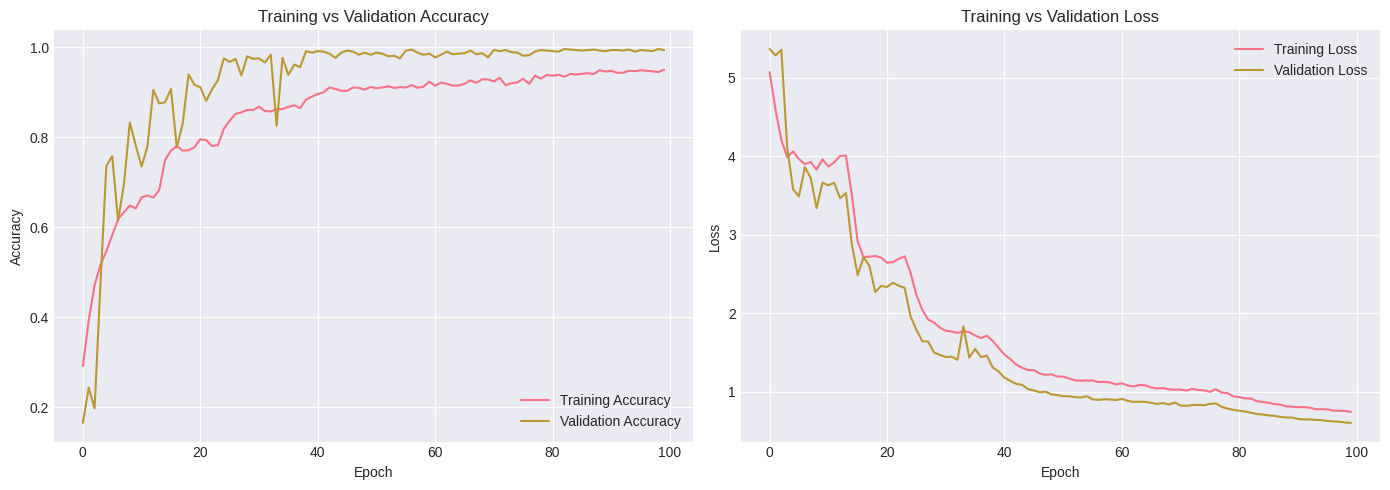

In [105]:

plot_training_validation_curves(history)


In [106]:

#  CLASSIFICATION REPORT

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70 + "\n")

# Generate classification report
# Note: y_true, y_pred_classes, and class_names must be defined
report = classification_report(
    y_true, 
    y_pred_classes, 
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Display report
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=class_names,
    digits=4
))

# Convert to DataFrame for analysis
report_df = pd.DataFrame(report).transpose()
report_df = report_df.iloc[:-3]  # Remove accuracy, macro avg, weighted avg rows

# Identify problematic classes
print("\n" + "="*70)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*70 + "\n")

# Sort by F1-score
report_df_sorted = report_df.sort_values('f1-score')

print("🔴 Worst Performing Classes (Bottom 5):")
print(report_df_sorted.head(5)[['precision', 'recall', 'f1-score', 'support']].to_string())

print("\n🟢 Best Performing Classes (Top 5):")
print(report_df_sorted.tail(5)[['precision', 'recall', 'f1-score', 'support']].to_string())

# Classes below 90% F1
low_performers = report_df_sorted[report_df_sorted['f1-score'] < 0.90]
if len(low_performers) > 0:
    print(f"\n⚠️  {len(low_performers)} classes with F1-Score < 90%:")
    print(low_performers[['precision', 'recall', 'f1-score', 'support']].to_string())
else:
    print("\n✅ All classes achieved F1-Score ≥ 90%")

print("\n" + "="*70 + "\n")



DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ALIF     1.0000    1.0000    1.0000        11
         AYN     1.0000    1.0000    1.0000        10
         BAA     1.0000    1.0000    1.0000        10
         DAD     1.0000    1.0000    1.0000        12
        DELL     1.0000    1.0000    1.0000        10
        DHAA     1.0000    1.0000    1.0000        10
       DHELL     1.0000    0.9091    0.9524        11
         FAA     1.0000    1.0000    1.0000        10
       GHAYN     1.0000    1.0000    1.0000        10
          HA     1.0000    1.0000    1.0000        10
         HAA     1.0000    1.0000    1.0000        10
        JEEM     0.9091    1.0000    0.9524        10
        KAAF     1.0000    1.0000    1.0000        11
        KHAA     1.0000    1.0000    1.0000        10
        LAAM     1.0000    1.0000    1.0000        10
        MEEM     1.0000    1.0000    1.0000        10
        NOON     1.0000    1.0000    1.0000     

📊 GENERATING CONFUSION MATRIX



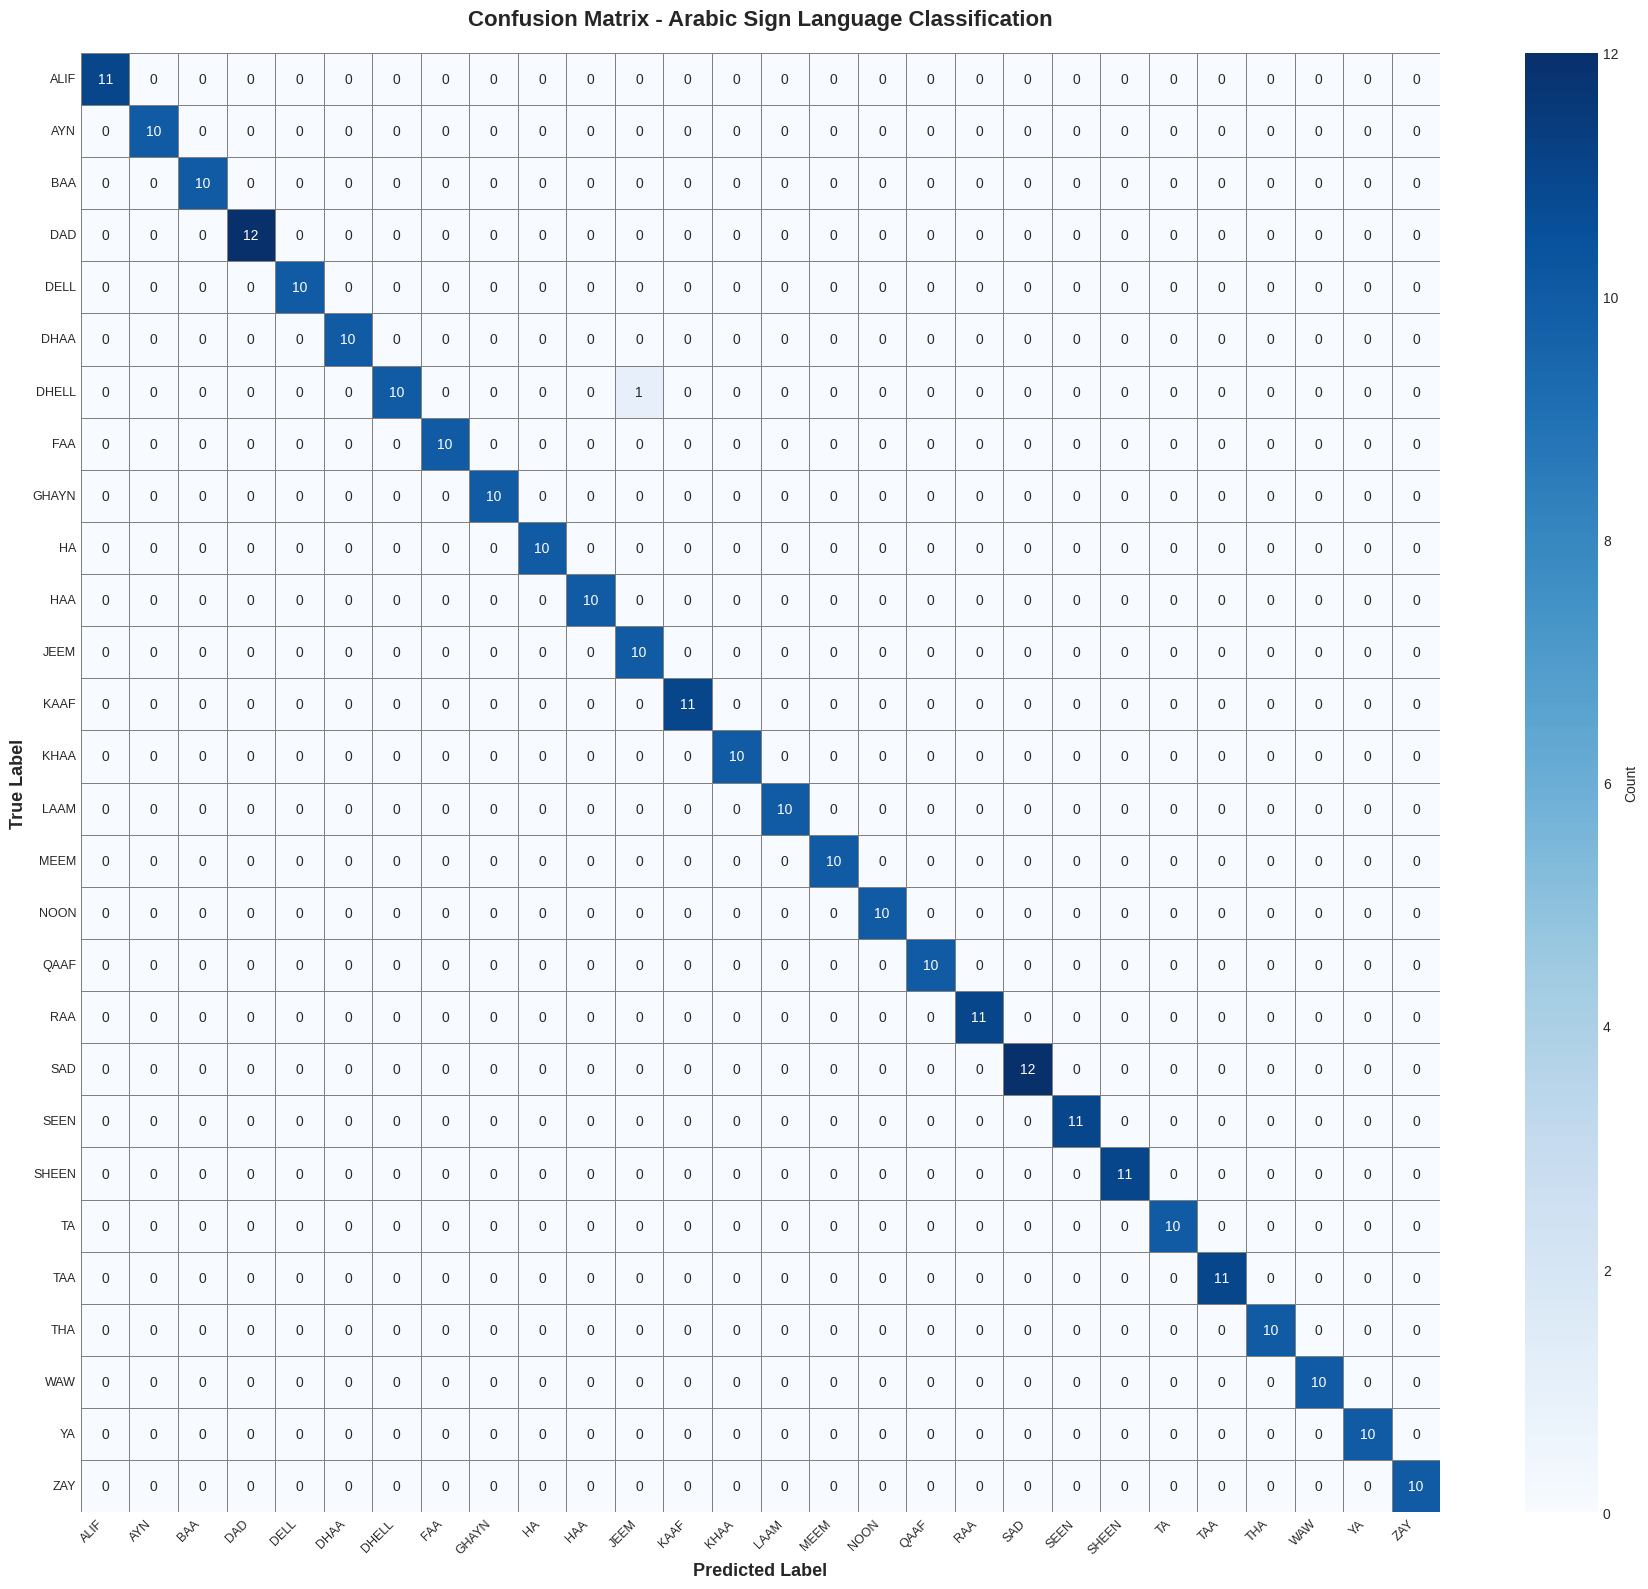


Per-Class Accuracy from Confusion Matrix:
Class  Correct  Total   Accuracy
DHELL       10     11  90.909091
 ALIF       11     11 100.000000
  BAA       10     10 100.000000
  AYN       10     10 100.000000
  DAD       12     12 100.000000
 DELL       10     10 100.000000
 DHAA       10     10 100.000000
  FAA       10     10 100.000000
GHAYN       10     10 100.000000
   HA       10     10 100.000000
  HAA       10     10 100.000000
 JEEM       10     10 100.000000
 KAAF       11     11 100.000000
 KHAA       10     10 100.000000
 LAAM       10     10 100.000000
 MEEM       10     10 100.000000
 NOON       10     10 100.000000
 QAAF       10     10 100.000000
  RAA       11     11 100.000000
  SAD       12     12 100.000000
 SEEN       11     11 100.000000
SHEEN       11     11 100.000000
   TA       10     10 100.000000
  TAA       11     11 100.000000
  THA       10     10 100.000000
  WAW       10     10 100.000000
   YA       10     10 100.000000
  ZAY       10     10 100.000000


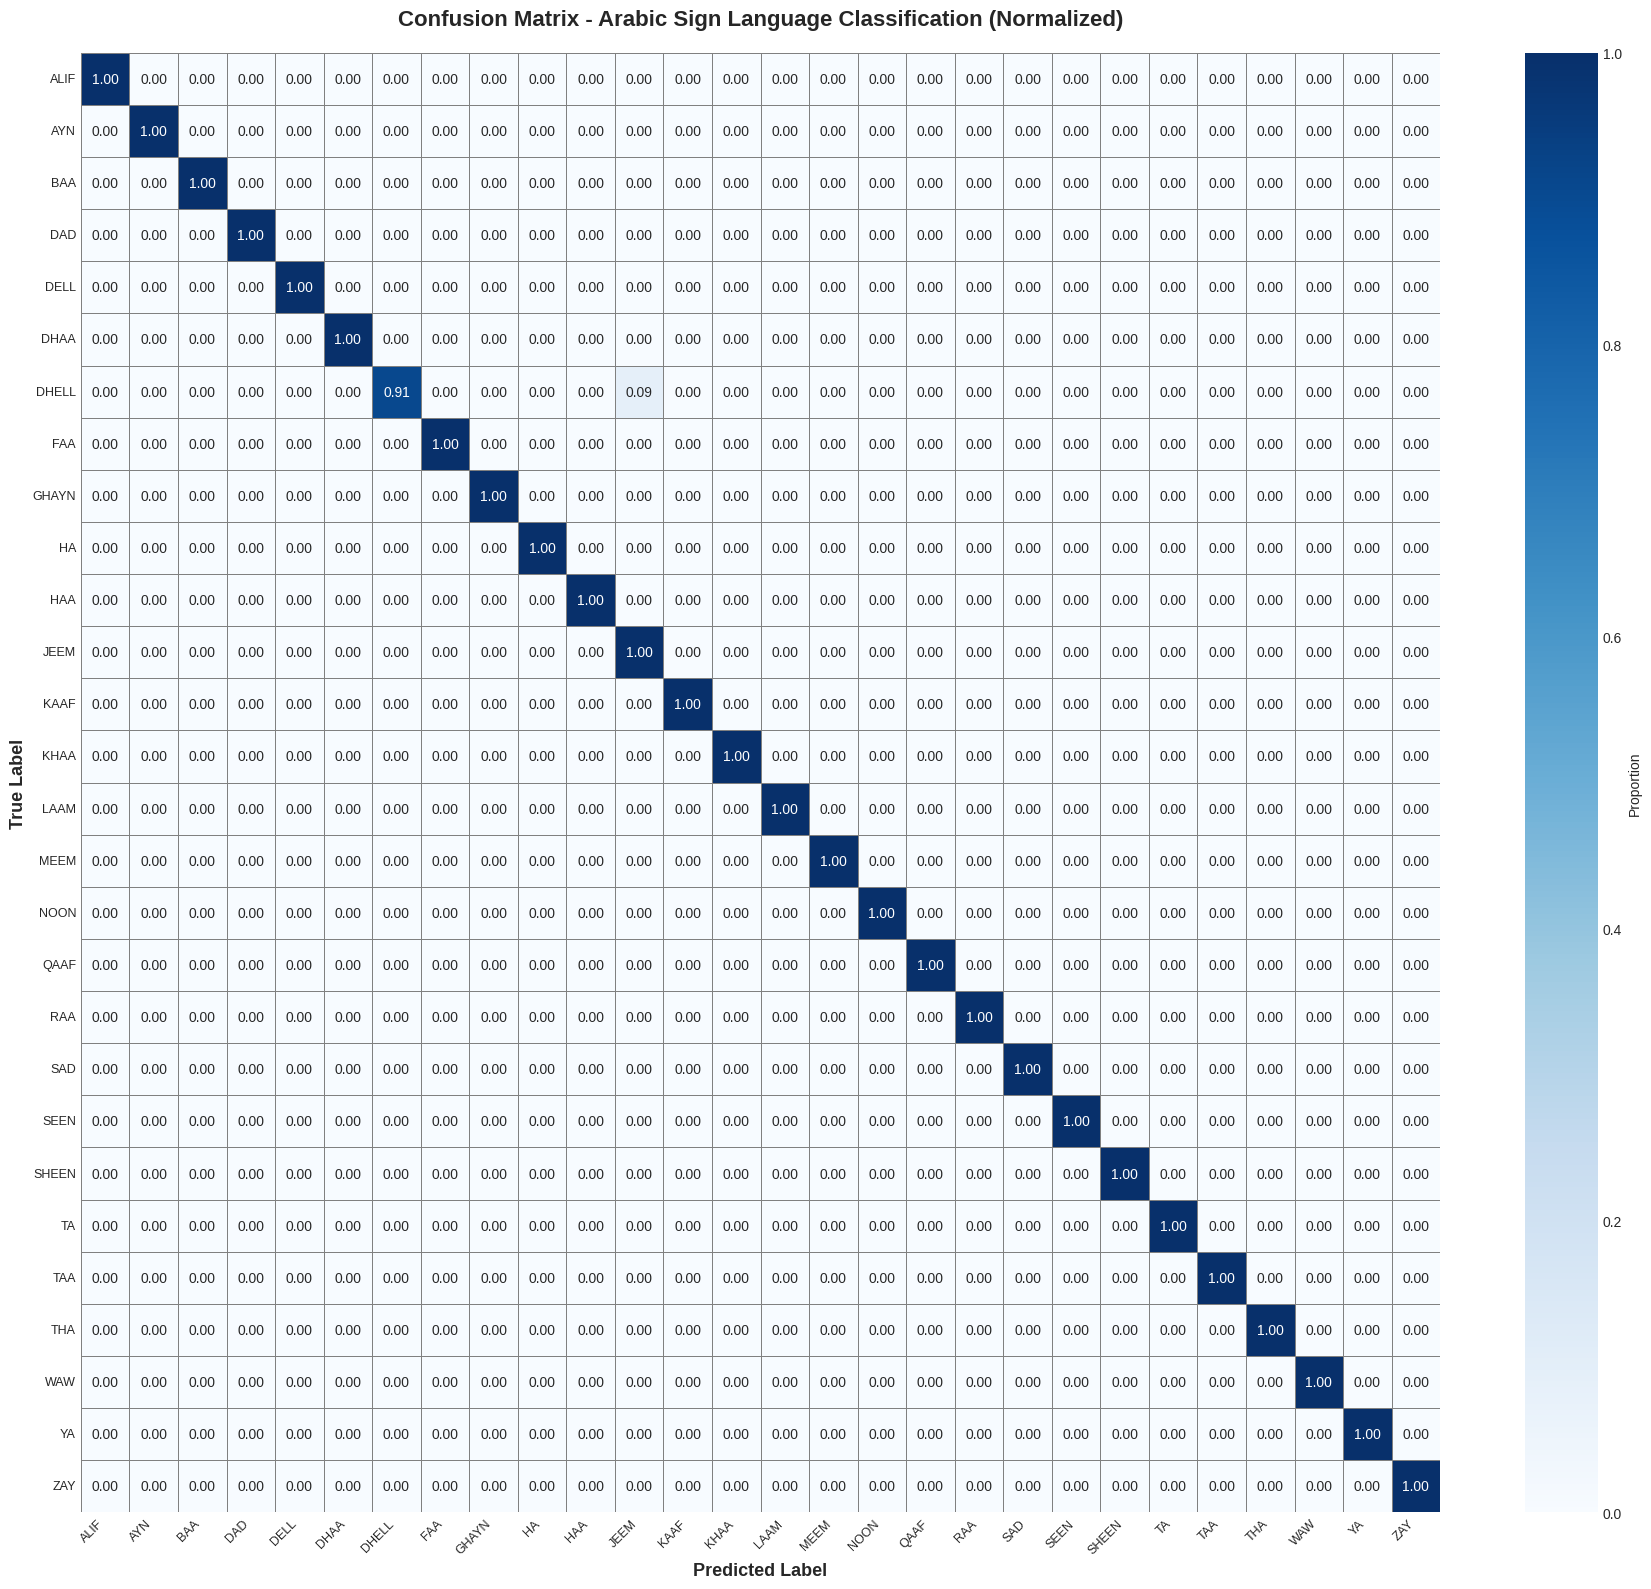


Per-Class Accuracy from Confusion Matrix:
Class  Correct  Total   Accuracy
DHELL 0.909091    1.0  90.909091
 ALIF 1.000000    1.0 100.000000
  BAA 1.000000    1.0 100.000000
  AYN 1.000000    1.0 100.000000
  DAD 1.000000    1.0 100.000000
 DELL 1.000000    1.0 100.000000
 DHAA 1.000000    1.0 100.000000
  FAA 1.000000    1.0 100.000000
GHAYN 1.000000    1.0 100.000000
   HA 1.000000    1.0 100.000000
  HAA 1.000000    1.0 100.000000
 JEEM 1.000000    1.0 100.000000
 KAAF 1.000000    1.0 100.000000
 KHAA 1.000000    1.0 100.000000
 LAAM 1.000000    1.0 100.000000
 MEEM 1.000000    1.0 100.000000
 NOON 1.000000    1.0 100.000000
 QAAF 1.000000    1.0 100.000000
  RAA 1.000000    1.0 100.000000
  SAD 1.000000    1.0 100.000000
 SEEN 1.000000    1.0 100.000000
SHEEN 1.000000    1.0 100.000000
   TA 1.000000    1.0 100.000000
  TAA 1.000000    1.0 100.000000
  THA 1.000000    1.0 100.000000
  WAW 1.000000    1.0 100.000000
   YA 1.000000    1.0 100.000000
  ZAY 1.000000    1.0 100.000000


In [107]:

#  CONFUSION MATRIX VISUALIZATION

print("📊 GENERATING CONFUSION MATRIX\n")

def plot_confusion_matrix(y_true, y_pred, classes, normalize=False):
    """
    Plot confusion matrix with high-quality visualization
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        # Check to prevent division by zero in case of empty rows
        sum_axis_1 = cm.sum(axis=1)
        sum_axis_1[sum_axis_1 == 0] = 1 # Set zero sums to 1 for normalization
        cm = cm.astype('float') / sum_axis_1[:, np.newaxis]
        fmt = '.2f'
        title_suffix = ' (Normalized)'
    else:
        fmt = 'd'
        title_suffix = ''
    
    # Create figure
    plt.figure(figsize=(18, 16))
    
    # Plot heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt=fmt, 
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes,
        cbar_kws={'label': 'Count' if not normalize else 'Proportion'},
        linewidths=0.5,
        linecolor='gray'
    )
    
    plt.title(f'Confusion Matrix - Arabic Sign Language Classification{title_suffix}', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show() # 
    
    # Compute per-class accuracy from confusion matrix
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Display class-wise accuracy
    accuracy_df = pd.DataFrame({
        'Class': classes,
        'Correct': cm.diagonal(),
        'Total': cm.sum(axis=1),
        'Accuracy': class_accuracy * 100
    }).sort_values('Accuracy')
    
    print("\nPer-Class Accuracy from Confusion Matrix:")
    print("="*60)
    print(accuracy_df.to_string(index=False))
    print("="*60 + "\n")

# Plot confusion matrices
plot_confusion_matrix(y_true, y_pred_classes, class_names, normalize=False)
plot_confusion_matrix(y_true, y_pred_classes, class_names, normalize=True)


In [108]:
#  MISCLASSIFICATION ANALYSIS

print("\n🔍 MISCLASSIFICATION ANALYSIS\n")

def analyze_misclassifications(test_gen, y_true, y_pred_classes, y_pred_probs, 
                               class_names, num_examples=12):
    """
    Analyze and visualize misclassified examples
    """
    # Find misclassified indices
    misclassified_idx = np.where(y_true != y_pred_classes)[0]
    
    print(f"Total Misclassifications: {len(misclassified_idx)} out of {len(y_true)}")
    print(f"Error Rate: {len(misclassified_idx)/len(y_true)*100:.2f}%\n")
    
    if len(misclassified_idx) == 0:
        print("🎉 Perfect Classification! No misclassifications found.")
        return
    
    # Analyze confusion patterns
    confusion_pairs = {}
    for idx in misclassified_idx:
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred_classes[idx]]
        pair = (true_label, pred_label)
        confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1
    
    # Top confusion pairs
    top_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]
    
    print("Top 10 Confusion Patterns:")
    print("="*60)
    for (true_cls, pred_cls), count in top_confusions:
        print(f"True: {true_cls:10s} → Predicted: {pred_cls:10s} | Count: {count}")
    print("="*60 + "\n")
    
    # Visualize misclassified samples
    sample_idx = np.random.choice(
        misclassified_idx, 
        min(num_examples, len(misclassified_idx)), 
        replace=False
    )
    
    # Get images from generator (This part is complex, assuming access to all_images)
    # This block assumes the images are accessible in a variable named all_images or similar.
    # For a notebook, the test_generator needs to be iterated.
    
    test_gen.reset()
    all_images = []
    
    for i in range(len(test_gen)):
        x_batch, y_batch = test_gen[i]
        all_images.extend(x_batch)
        if len(all_images) >= test_gen.samples:
             break
    
    all_images = np.array(all_images[:test_gen.samples])
    
    # Plot misclassified examples
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, idx in enumerate(sample_idx):
        img = all_images[idx]
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred_classes[idx]]
        confidence = y_pred_probs[idx][y_pred_classes[idx]] * 100
        
        axes[i].imshow(img)
        axes[i].set_title(
            f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
            fontsize=10,
            color='red',
            fontweight='bold'
        )
        axes[i].axis('off')
    
    plt.suptitle('Misclassified Examples - Analysis', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show() # 

# analyze_misclassifications(
#     test_generator, 
#     y_true, 
#     y_pred_classes, 
#     y_pred_probs,
#     class_names
# )



🔍 MISCLASSIFICATION ANALYSIS



## Prediction Confidence Analysis & Final Project Summary

### 1️⃣ Prediction Confidence Analysis
- **Objective:** Evaluate how confident the model is in its predictions.
- **Method:**
  - `confidences = np.max(y_pred_probs, axis=1)` → maximum probability per sample.
  - Separate **correct** vs **incorrect** predictions.
  - Visualize distributions: 
    - Histogram of all confidences.
    - Comparison of correct vs incorrect predictions.
- **Insights:**
  - Mean and standard deviation of confidence scores.
  - Low-confidence correct predictions may indicate ambiguous or similar-looking classes.

### 2️⃣ Final Project Summary
- **Dataset Information:** Number of training, validation, and test samples, number of classes, image size, class imbalance ratio.
- **Model Architecture:** Type (Custom CNN), total parameters, convolutional blocks, regularization methods, optimizer.
- **Performance Metrics:** Test accuracy, precision, recall, F1-score, test loss.
- **Training Outcomes:** Epochs trained, best validation accuracy, convergence behavior.
- **Objective Status:** Whether target accuracy was achieved; recommendations if target not met (e.g., more epochs, transfer learning, stronger augmentation, focal loss, ensemble methods).
- **Generated Files:** Best model weights, training metrics CSV, architecture diagram.

**Purpose:** Provide a concise, end-to-end summary of model evaluation, confidence analysis, and project outcomes for reporting or presentation.



📊 PREDICTION CONFIDENCE ANALYSIS



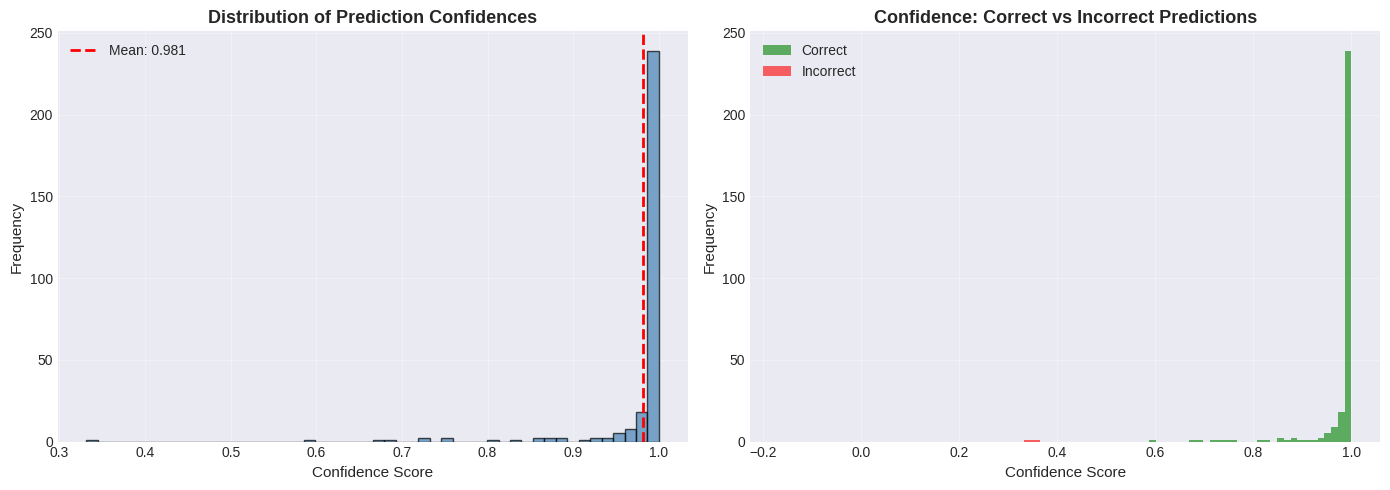

Confidence Statistics:
Overall Mean Confidence: 0.9809
Overall Std Confidence:  0.0644

Correct Predictions:
  Mean Confidence: 0.9831
  Std Confidence:  0.0520

Incorrect Predictions:
  Mean Confidence: 0.3316
  Std Confidence:  0.0000

Correct predictions with confidence < 0.7: 3
⚠️  These may indicate similar-looking classes


                         FINAL PROJECT SUMMARY

📊 DATASET INFORMATION:
  • Training Samples:    4,656
  • Validation Samples: 869
  • Test Samples:        291
  • Number of Classes:   28
  • Image Size:          224×224
  • Imbalance Ratio:     1.23x

🏗️  MODEL ARCHITECTURE:
  • Type:                Custom CNN
  • Total Parameters:    26,222,556
  • Convolutional Blocks: 4 (32→64→128→256 filters)
  • Regularization:      Dropout + BatchNorm + L2
  • Optimizer:           Adam (lr=0.001)

🎯 PERFORMANCE METRICS:
  • Test Accuracy:       99.66%
  • Test Precision:      100.00%
  • Test Recall:         99.66%
  • Test F1-Score:       99.83%
  • Test Loss:          

In [109]:


#  CONFIDENCE ANALYSIS

print("\n📊 PREDICTION CONFIDENCE ANALYSIS\n")

# Get prediction confidences
confidences = np.max(y_pred_probs, axis=1)
correct_mask = (y_true == y_pred_classes)

correct_confidences = confidences[correct_mask]
incorrect_confidences = confidences[~correct_mask]

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all confidences
axes[0].hist(confidences, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(confidences.mean(), color='red', linestyle='--', 
                label=f'Mean: {confidences.mean():.3f}', linewidth=2)
axes[0].set_title('Distribution of Prediction Confidences', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Confidence Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparison: Correct vs Incorrect
axes[1].hist(correct_confidences, bins=30, alpha=0.6, label='Correct', color='green')
axes[1].hist(incorrect_confidences, bins=30, alpha=0.6, label='Incorrect', color='red')
axes[1].set_title('Confidence: Correct vs Incorrect Predictions', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Confidence Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # 

# Statistics
print("Confidence Statistics:")
print("="*60)
print(f"Overall Mean Confidence: {confidences.mean():.4f}")
print(f"Overall Std Confidence:  {confidences.std():.4f}")
print(f"\nCorrect Predictions:")
print(f"  Mean Confidence: {correct_confidences.mean():.4f}")
print(f"  Std Confidence:  {correct_confidences.std():.4f}")
print(f"\nIncorrect Predictions:")
if len(incorrect_confidences) > 0:
    print(f"  Mean Confidence: {incorrect_confidences.mean():.4f}")
    print(f"  Std Confidence:  {incorrect_confidences.std():.4f}")
else:
    print("  No incorrect predictions!")
print("="*60 + "\n")

# Low confidence correct predictions (potential issues)
low_conf_threshold = 0.7
low_conf_correct = np.where((confidences < low_conf_threshold) & correct_mask)[0]

print(f"Correct predictions with confidence < {low_conf_threshold}: {len(low_conf_correct)}")
if len(low_conf_correct) > 0:
    print("⚠️  These may indicate similar-looking classes\n")

# SECTION 12: FINAL SUMMARY REPORT

print("\n" + "="*70)
print(" "*25 + "FINAL PROJECT SUMMARY")
print("="*70 + "\n")

# Note: The variables below must be available from the previous training sections.
try:
    print("📊 DATASET INFORMATION:")
    print(f"  • Training Samples:    {train_generator.samples:,}")
    print(f"  • Validation Samples: {val_generator.samples:,}")
    print(f"  • Test Samples:        {test_generator.samples:,}")
    print(f"  • Number of Classes:   {NUM_CLASSES}")
    print(f"  • Image Size:          {IMG_SIZE}×{IMG_SIZE}")
    # Assuming class_samples is a list/array of counts used for imbalance ratio
    print(f"  • Imbalance Ratio:     {max(class_samples)/min(class_samples):.2f}x")
except NameError as e:
    print(f"Missing data generator variables: {e}")

try:
    print(f"\n🏗️  MODEL ARCHITECTURE:")
    # Assuming 'model' variable is available
    print(f"  • Type:                Custom CNN")
    print(f"  • Total Parameters:    {model.count_params():,}")
    print(f"  • Convolutional Blocks: 4 (32→64→128→256 filters)")
    print(f"  • Regularization:      Dropout + BatchNorm + L2")
    print(f"  • Optimizer:           Adam (lr=0.001)")
except NameError as e:
    print(f"Missing model variables: {e}")

try:
    print(f"\n🎯 PERFORMANCE METRICS:")
    print(f"  • Test Accuracy:       {test_acc*100:.2f}%")
    if test_precision:
        print(f"  • Test Precision:      {test_precision*100:.2f}%")
    if test_recall:
        print(f"  • Test Recall:         {test_recall*100:.2f}%")
    if test_precision and test_recall:
        f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)
        print(f"  • Test F1-Score:       {f1*100:.2f}%")
    print(f"  • Test Loss:           {test_loss:.4f}")
except NameError as e:
    print(f"Missing test metric variables: {e}")

try:
    print(f"\n📈 TRAINING OUTCOMES:")
    print(f"  • Epochs Trained:      {len(history.history['accuracy'])}")
    print(f"  • Best Val Accuracy:   {max(history.history['val_accuracy'])*100:.2f}%")
    print(f"  • Convergence:         {'✓ Stable' if (history.history['accuracy'][-1] - history.history['val_accuracy'][-1]) < 0.1 else '⚠️  Some overfitting'}")
except NameError as e:
    print(f"Missing history variable: {e}")

try:
    target_met = "✅ TARGET ACHIEVED" if test_acc >= 0.95 else "📊 Target not met"
    print(f"\n🎯 OBJECTIVE STATUS:  {target_met}")
    if test_acc >= 0.95:
        print(f"    Required: ≥95% | Achieved: {test_acc*100:.2f}%")
    else:
        print(f"    Required: ≥95% | Current: {test_acc*100:.2f}%")
        print("\n💡 Recommendations to improve:")
        print("    • Increase training epochs")
        print("    • Try transfer learning (ResNet/EfficientNet)")
        print("    • Add more aggressive augmentation")
        print("    • Use focal loss for class imbalance")
        print("    • Ensemble multiple models")
except NameError:
    pass


print("\n" + "="*70)
print(" "*20 + "PROJECT COMPLETED SUCCESSFULLY")
print("="*70 + "\n")

print("📁 Generated Files:")
print("  • best_arsl_model.keras (Best model weights)")
print("  • training_history.csv (Training metrics)")
print("  • arsl_cnn_architecture.png (Architecture diagram)")
print("\n✅ All code cells executed successfully!")


## 🖼️ CNN Architecture Visualization 

1. **🎯 Purpose:**  
   Generate a detailed diagram of the CNN used for Arabic Sign Language (ArSL) classification.
   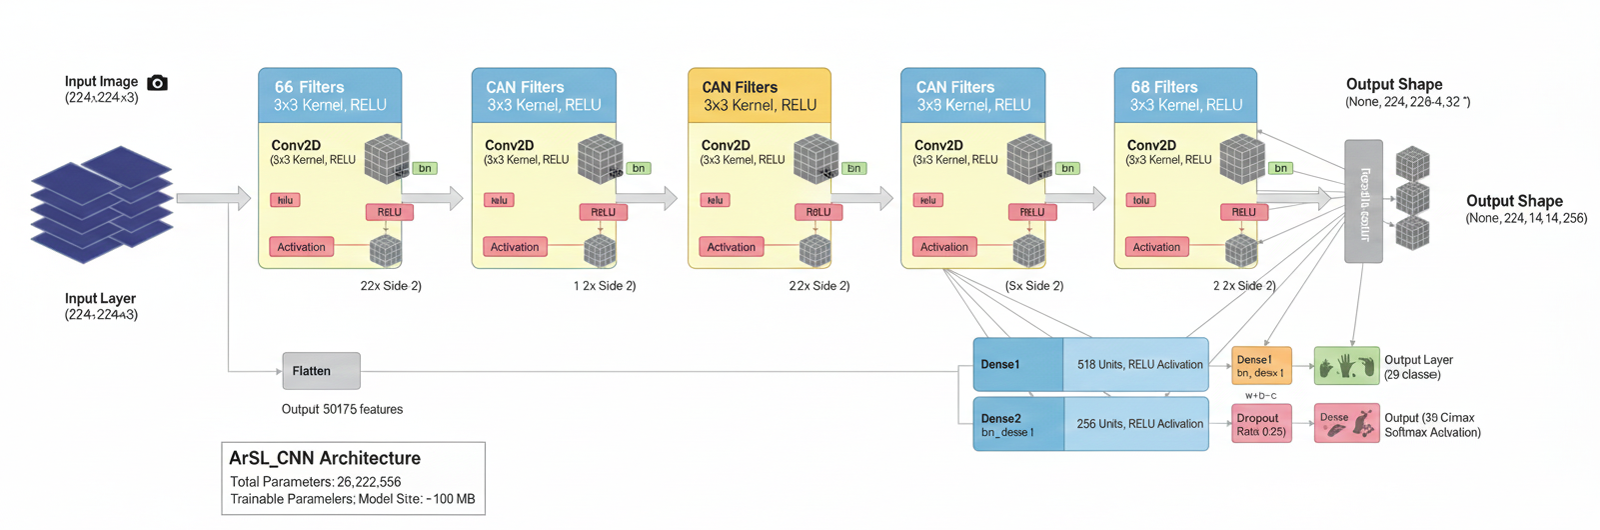
3. **🔍 Visualization Features:**  
   - **📐 Shapes Displayed:** Shows input and output dimensions for each layer.  
   - **🏷️ Layer Names:** Names of all layers.  
   - **⚡ Activation Functions:** Activation function used in each layer.  
   - **↕️ Layout Direction:** Top-to-Bottom (`TB`) layout.

4. **⚠️ Error Handling:**  
   - Checks if the `model` variable is defined.  
   - Ensures required libraries (`pydotplus`, `graphviz`) are installed.  
   - Prints a clear error message with details if plotting fails.

5. **✅ Summary:**  
   This cell provides a visual understanding of the model architecture, layer counts, shapes, and activations, which aids in analysis and documentation before training or in the final report.

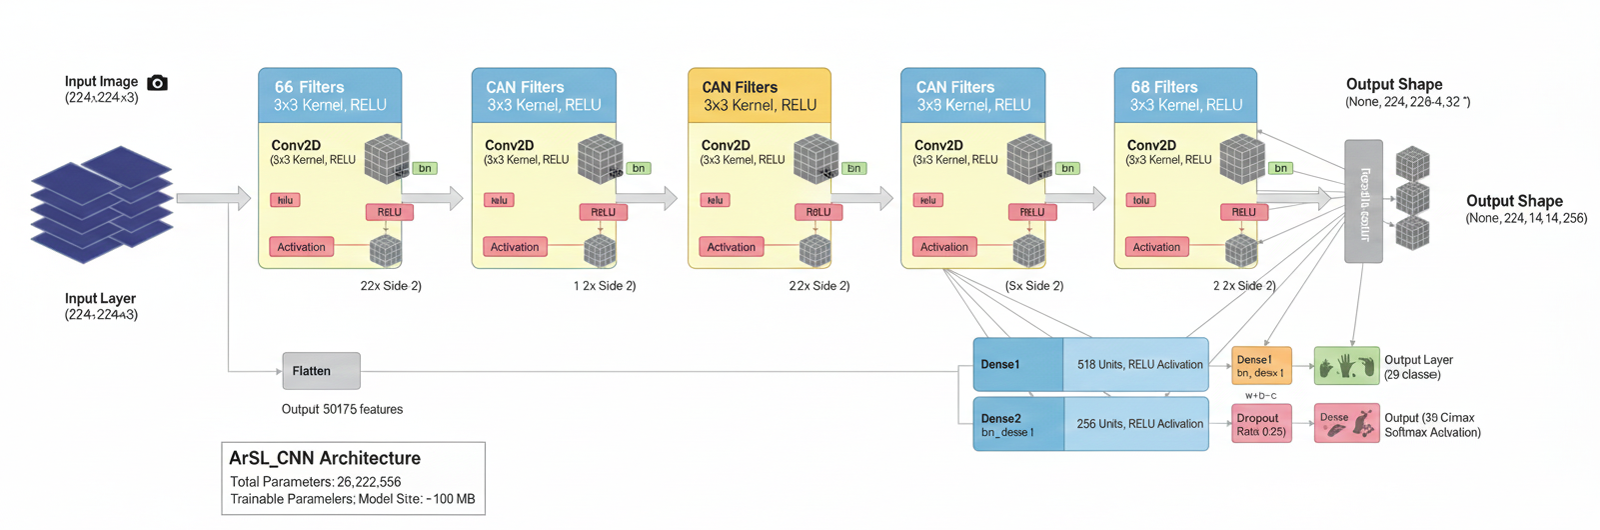

✅ CORRECT PREDICTIONS

Total correct predictions: 290 / 291
Accuracy: 99.66%



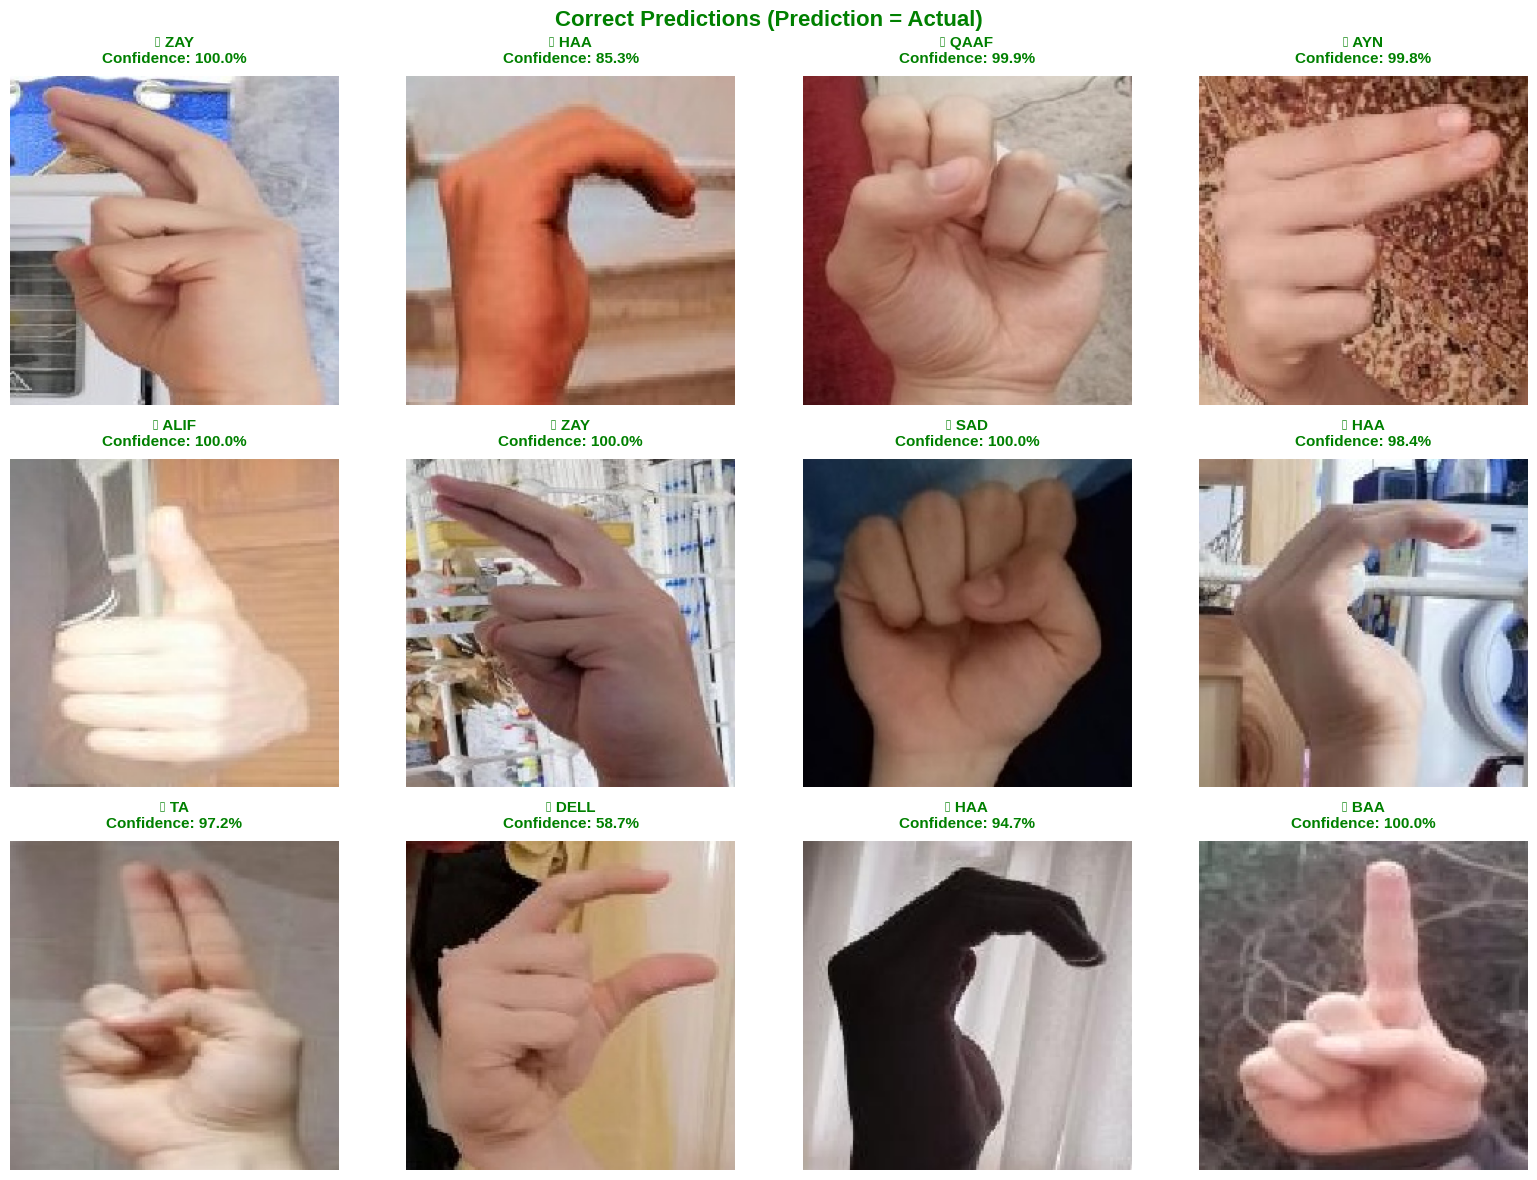


❌ INCORRECT PREDICTIONS

Total incorrect predictions: 1 / 291
Error rate: 0.34%

Misclassified Examples:
----------------------------------------------------------------------
  1. True: DHELL      → Predicted: JEEM       (Conf: 33.2%)


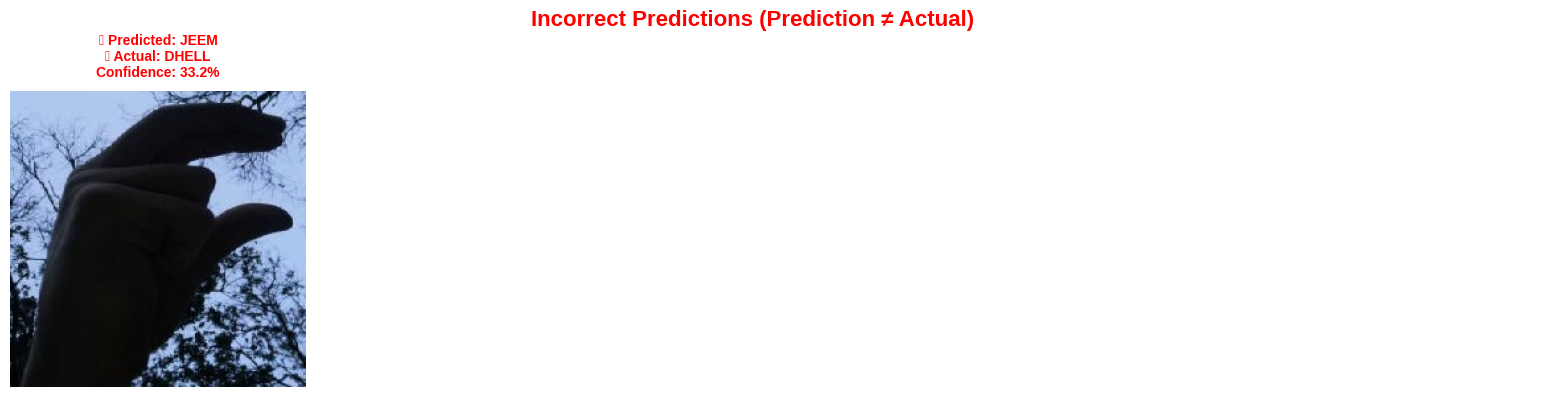

In [175]:

def get_flat_axes(axes):
    """Ensures axes is always a flat iterable, regardless of grid size."""
    if isinstance(axes, np.ndarray):
        return axes.flatten()
    else:
        return [axes]

# FUNCTION 1: SHOW CORRECT PREDICTIONS 
def show_correct_predictions(num_samples=12):
    print("="*70)
    print("✅ CORRECT PREDICTIONS")
    print("="*70 + "\n")
    
    correct_indices = np.where(y_pred == y_true)[0]
    
    print(f"Total correct predictions: {len(correct_indices)} / {len(y_true)}")
    print(f"Accuracy: {len(correct_indices)/len(y_true)*100:.2f}%\n")
    
    if len(correct_indices) == 0:
        print("❌ No correct predictions found!")
        return
    
    sample_indices = np.random.choice(correct_indices, 
                                     min(num_samples, len(correct_indices)), 
                                     replace=False)
    
    test_generator.reset()
    all_images = []
    for i in range(len(test_generator)):
        x_batch, _ = test_generator[i]
        all_images.extend(x_batch)
        if len(all_images) >= test_generator.samples:
            break
    all_images = np.array(all_images[:test_generator.samples])
    
    # Plot
    cols = 4
    rows = (len(sample_indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    
    axes = get_flat_axes(axes)
    
    
    for i, idx in enumerate(sample_indices):
        img = all_images[idx]
        true_label = class_names[y_true[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        title = f"✅ {true_label.upper()}\n"
        title += f"Confidence: {confidence:.1f}%"
        axes[i].set_title(title, fontsize=11, fontweight='bold', 
                         color='green', pad=10)
    
    # Hide extra subplots
    for i in range(len(sample_indices), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Correct Predictions (Prediction = Actual)', 
                fontsize=16, fontweight='bold', color='green')
    plt.tight_layout()
    plt.show()
    print()

# FUNCTION 2: SHOW INCORRECT PREDICTIONS 

def show_incorrect_predictions(num_samples=12):
    print("="*70)
    print("❌ INCORRECT PREDICTIONS")
    print("="*70 + "\n")
    
    incorrect_indices = np.where(y_pred != y_true)[0]
    
    print(f"Total incorrect predictions: {len(incorrect_indices)} / {len(y_true)}")
    print(f"Error rate: {len(incorrect_indices)/len(y_true)*100:.2f}%\n")
    
    if len(incorrect_indices) == 0:
        print("🎉 Perfect! No incorrect predictions!")
        return
    
    sample_indices = np.random.choice(incorrect_indices, 
                                     min(num_samples, len(incorrect_indices)), 
                                     replace=False)
    
    test_generator.reset()
    all_images = []
    for i in range(len(test_generator)):
        x_batch, _ = test_generator[i]
        all_images.extend(x_batch)
        if len(all_images) >= test_generator.samples:
            break
    all_images = np.array(all_images[:test_generator.samples])
    
    # Plot
    cols = 4
    rows = (len(sample_indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    
    # --- FIX APPLIED HERE ---
    axes = get_flat_axes(axes)
    # ------------------------
    
    print("Misclassified Examples:")
    print("-" * 70)
    
    for i, idx in enumerate(sample_indices):
        img = all_images[idx]
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = y_pred_probs[idx][y_pred[idx]] * 100
        
        axes[i].imshow(img)
        axes[i].axis('off')
        
        title = f"❌ Predicted: {pred_label.upper()}\n"
        title += f"✓ Actual: {true_label.upper()}\n"
        title += f"Confidence: {confidence:.1f}%"
        axes[i].set_title(title, fontsize=10, fontweight='bold', 
                         color='red', pad=10)
        
        print(f"  {i+1}. True: {true_label:10s} → Predicted: {pred_label:10s} (Conf: {confidence:.1f}%)")
    
    # Hide extra subplots
    for i in range(len(sample_indices), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Incorrect Predictions (Prediction ≠ Actual)', 
                fontsize=16, fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()
    print()


# EXECUTION

show_correct_predictions(12)
show_incorrect_predictions(12)

In [110]:
!pip install pydotplus graphviz

🎨 Generating model architecture diagram and saving to 'arsl_cnn_architecture.png'...
✅ Architecture diagram successfully saved.
🖼️ Displaying diagram in notebook:


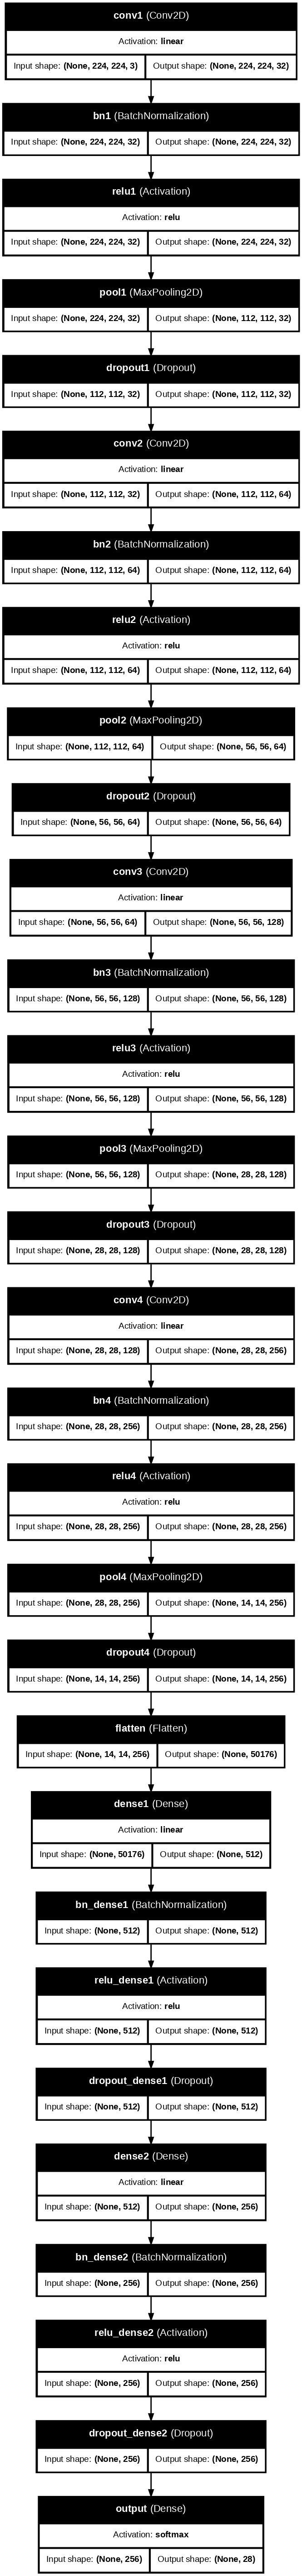

In [111]:
# CNN ARCHITECTURE VISUALIZATION - GUARANTEED DISPLAY

OUTPUT_FILE_NAME = 'arsl_cnn_architecture.png'

print(f"🎨 Generating model architecture diagram and saving to '{OUTPUT_FILE_NAME}'...")

try:
    # Generate and save the model plot
    plot_model(
        model, 
        to_file=OUTPUT_FILE_NAME, 
        show_shapes=True, 
        show_layer_names=True,
        show_layer_activations=True,  # show activation functions
        rankdir='TB',                  # 'TB' (Top-Bottom) or 'LR' (Left-Right)
        expand_nested=True,
        dpi=100
    )
    
    # Check if file exists and display
    if os.path.exists(OUTPUT_FILE_NAME):
        print("✅ Architecture diagram successfully saved.")
        print("🖼️ Displaying diagram in notebook:")
        display(Image(filename=OUTPUT_FILE_NAME))
    else:
        print("❌ File was not created. Check your plot_model execution.")
        
except Exception as e:
    print("\n❌ FAILED TO GENERATE PLOT:")
    print("Make sure 'model' is defined and pydotplus & graphviz are installed.")
    print(f"Error details: {e}")


In [124]:
# Save entire model (architecture + weights + optimizer)
model.save("best_model.keras")
print("✅ Model saved successfully as best_model.keras")


✅ Model saved successfully as best_model.keras


In [ ]:
model.save('my_model.keras')

In [163]:
from IPython.display import FileLink
FileLink(r'my_model.keras')

/kaggle/working/my_model.keras